# Spectral response

The purpose of this script is to cross check the zero-points and magnitudes of the PLATO N-CAM, F-CAM blue, and F-CAM red response of PlatoSim versus that reported in PLATO-DLR-PL-TN-0113.

Creator: 2024-12-18 - Juan Cabrera 

Updated: 2025-01-07 - Nicholas Jannsen  (Git tracking started)
```
commit 7a3f254e05bc0fed4dce1c4c1c690f7e361717c1
```
Updated: 2025-04-14 - Juan Cabrera
```
commit 3d9d65decc3acff853702e52150828c29197a76b
```
Updated: 2025-04-22 - Nicholas Jannsen (TE discrepancy solved)
```
commit 02cebe49def86d27f2b855ede64126dbb7d062a7
```
Updated: 2025-05-22 - Juan Cabrera (TE discrepancy confirmed)
```
commit 930dc214e3fb7be1bae2eabdadef273732fd7fda
```
Updated: 2025-06-02 - Nicholas Jannsen (Made new analysis of zero-point flux discrepancy)
```
commit 311ec39adb5b36d785544a91b9bc3e2b455ddf00
```
Updated: 2025-06-03 - Juan Cabrera (Founc a few bugs with the bandwith and F-CAM TE designed)
```
commit e755d1b8a8b76521a5b63c86eb747432961005fd
```

---
## 1. Imports & Downloads
---

In [1]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# To interact with the plot use
%matplotlib notebook

# Juan: I had to add this line to avoid some issues with the plots
# %matplotlib ipympl

In [2]:
import os
import scipy
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm

# PlatoSim
import platosim.plot            as pt
import platosim.utilities       as ut
import platosim.referenceFrames as rf
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.matplotlibrc import setup_notebook
setup_notebook(warning=False)

# Expand width of notebook
from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

In [3]:
# Download files on KUL FTP needed for this notebook
ut.downloadFromFTP('optical_transmission_ncam_v2.csv', '.')
ut.downloadFromFTP('optical_transmission_fcam_v2.csv', '.')

---
## 2. PlatoSim's wavelength dependent parameters
---

PlatoSim will incorporate the impact of wavelength dependent efficiency factors (optical transmission of the lenses, quantum efficiency, filter transmission) as wavelength-averaged factors. The numerical values are computed with the function 'estimate_quantity' below.

Additionally, PlatoSim considers the central wavelength (`Camera/ThroughputLambdaC`) and bandwith pass (`Camera/ThroughputBandwidth`) of each camera. These parameter, together with `Fluxm0`, determine the computation of photons that is later converted into photolectrons when including the different efficiency factors (and vigentting, where appropriate).

In [4]:
def estimate_quantity(dictionary, 
                      quantity, 
                      performance='Required', 
                      time='BOL', 
                      camera='all', 
                      plot=True):
    """Small function to quickly plot the QE and TE.
    
    This function takes as input a dictionary with a mandatory keyword ('wl') 
    and optional keyword which is built combining the parameters provided to the
    function, namely keyword = f'{quantity}_{performance}_{time}'.The function
    processes N-CAM and F-CAM blue and red using cutoffs that are taken from the
    requirements. Therefore, not identical to the 'as built' filters. 
    
    The function will take the optional keyword (f'{quantity}_{performance}_{time}'),
    will make a spline interpolation, will integrate the area below the interpolated
    curve with a trapezoidal function from numpy, and return the area below the curve.
    The function returns a list with the area below the curve, but two of the values
    might be None depending on the value of the parameter 'camera':
        - If 'camera' is 'all', then the function returns the area below the curve
          (for the whole wavelength interval, for the blue interval, for the red interval).
        - If 'camera' is 'ncam', then the function returns the area 
          (for the whole wavelength interval, None, None).
        - If 'camera' is 'blue', then the function returns the area 
          (None, for the blue interval, None).
        - If 'camera' is 'red', then the function returns the area
          (None, None, for the red interval).
          
    Juan 03.06.2025
    We have modified the function so it computes as well reasonable approximations
    for the PlatoSim configuration parameters Camera/ThroughputBandwidth and
    Camera/ThroughputLambdaC.
    
    Naively, Camera/ThroughputBandwidth should encompass the interval of wavelenths
    'wl_int' where the spline interpolation 'xx_int' has positive values, with special
    attention to the F-CAMs. Then Camera/ThroughputLambdaC is the mid-point of this
    interval.
    
    Not so naively, we could have computed the central wavelength weighting the
    transmission, but we have decided not to do so.
    """ 
    wl = dictionary['wl']
    xx = dictionary[f'{quantity}_{performance}_{time}']
    
    dex_nan = np.isnan(xx)
    wl = wl[~dex_nan]
    xx = xx[~dex_nan]
    
    grid_no = 500
    wl_int = np.linspace(wl[0], wl[-1], grid_no)                                                                                                                                         
    spline = scipy.interpolate.make_interp_spline(wl, xx, k=3)                                                                                                                                             
    xx_int = spline(wl_int)

    print(f'{quantity}: As {performance} {time}')
    
    dex_665 = ut.findNearestIndex(wl_int, 665)
    dex_700 = ut.findNearestIndex(wl_int, 700)
    
    if camera in ['all', 'ncam']:
        # we compute the average efficiency in the interval
        xx_NCAM = np.trapz(xx_int / (len(wl_int) - 1))
        # we compute Camera/ThroughputLambdaC and Camera/ThroughputBandwidth
        positive_spline_interpolation = np.where( xx_int > 0.)[ 0]
        left_border_wavelength_interval  = wl_int[ positive_spline_interpolation[  0]]
        right_border_wavelength_interval = wl_int[ positive_spline_interpolation[ -1]]
        throughput_bandwidth = right_border_wavelength_interval - left_border_wavelength_interval
        throughput_lamda_c   = 0.5*( left_border_wavelength_interval + right_border_wavelength_interval)
        # we report the results
        print(f"N-CAM     : {xx_NCAM:.6f}; Camera/ThroughputLambdaC {throughput_lamda_c:.1f}; Camera/ThroughputBandwidth {throughput_bandwidth:.1f}")
    else: 
        xx_NCAM = None
        
    if camera in ['all', 'blue']:
        # we compute the average efficiency in the interval
        xx_FCAM_blue = np.trapz(xx_int[:dex_700] / (len(wl_int[:dex_700]) - 1))
        # we compute Camera/ThroughputLambdaC and Camera/ThroughputBandwidth
        positive_spline_interpolation = np.where( xx_int > 0.)[ 0]
        left_border_wavelength_interval  = wl_int[ positive_spline_interpolation[  0]]
        right_border_wavelength_interval = wl_int[ dex_700]
        throughput_bandwidth = right_border_wavelength_interval - left_border_wavelength_interval
        throughput_lamda_c   = 0.5*( left_border_wavelength_interval + right_border_wavelength_interval)
        # we report the results
        print(f"F-CAM blue: {xx_FCAM_blue:.6f}; Camera/ThroughputLambdaC {throughput_lamda_c:.1f}; Camera/ThroughputBandwidth {throughput_bandwidth:.1f}")
    else: 
        xx_FCAM_blue = None
        
    if camera in ['all', 'red']:
        # we compute the average efficiency in the interval
        xx_FCAM_red  = np.trapz(xx_int[dex_665:] / (len(wl_int[dex_665:]) - 1))
        # we compute Camera/ThroughputLambdaC and Camera/ThroughputBandwidth
        positive_spline_interpolation = np.where( xx_int > 0.)[ 0]
        left_border_wavelength_interval  = wl_int[ dex_665]
        right_border_wavelength_interval = wl_int[ positive_spline_interpolation[ -1]]
        throughput_bandwidth = right_border_wavelength_interval - left_border_wavelength_interval
        throughput_lamda_c   = 0.5*( left_border_wavelength_interval + right_border_wavelength_interval)
        # we report the results
        print(f"F-CAM red : {xx_FCAM_red:.6f}; Camera/ThroughputLambdaC {throughput_lamda_c:.1f}; Camera/ThroughputBandwidth {throughput_bandwidth:.1f}")
    else: 
        xx_FCAM_red = None

    # Plot figure
    if plot:
        xlim = [450, 1050]
        fig = plt.figure(figsize=(8,6))
        plt.axvspan(xlim[0], wl[0],  facecolor='0.2', alpha=0.3)
        plt.axvspan(wl[-1], xlim[1], facecolor='0.2', alpha=0.3)
        if camera in ['all', 'ncam']:
            plt.axhline(y=xx_NCAM, color='g', linestyle=':', linewidth=2, label = "N-CAM")
        if camera in ['all', 'blue']:
            plt.fill_between(wl_int[:dex_700], xx_int[:dex_700], color='blue', alpha=.1)
            plt.axhline(y=xx_FCAM_blue, color='b', linestyle=':', linewidth=2, label = "F-CAM blue")
        if camera in ['all', 'red']:
            plt.fill_between(wl_int[dex_665:], xx_int[dex_665:], color='red',  alpha=.1)
            plt.axhline(y=xx_FCAM_red,  color='r', linestyle=':', linewidth=2, label = "F-CAM red")
        plt.plot(wl_int, xx_int, 'k--')
        plt.plot(wl, xx, 'ko')
        plt.title(f"As {performance} {time}")
        plt.xlabel("Wavelength [nm]")
        plt.ylabel(quantity)
        plt.xlim(xlim)
        if quantity == 'QE':
            plt.ylim(0, 1)
        elif quantity == 'TE':
            plt.ylim(pt.getAxesMinMax(y=xx_int, percentage=5))
        plt.tight_layout();

    return xx_NCAM, xx_FCAM_blue, xx_FCAM_red

---
## 3. Transmission efficiency values
---

The transmission efficiency in PlatoSim includes only the **optical transmission** of the lenses.

The information that is contained in the Mission Parameter Database (MPDB), considers **camera effective transmission** which includes the optical transmission and the impact of particulate contamination (PAC),  of molecular contamination (MOC), and the transmissivity of the filters for the F-CAMs. PlatoSim includes also PAC and MOC when asessing the performance, but these parameters are configured in the yaml file separately (see `CCD\MolecularContaminationEfficiency` and `CCD\ParticulateContaminationEfficiency` configuration parameters).

Finally, at system level we consider the **camera throughput** which includes the camera effective transmission and the quantum efficiency of the CCDs (QE).

Therefore, to compare the system level analysis in PLATO-DLR-PL-TN-0113 and PlatoSim we have to be very careful when extracting the parameters from the MPDB, as we detail below.

For convenience, the optical transmission efficiency values are stored in dictionaries (`df`, `df_fcam`, etc.) that interface with the function `estimate_quantity()`.

| Scenario | Required BOL | Required EOL | Expected | Designed | Simulated |
|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|
| filter (only F-CAM) | required BOL | required EOL | required BOL | designed | designed |
| tranmission efficiency (lenses) | Anko's table | Anko's table | EM | PFM | PFM |
| PAC | required EOL | required EOL | required EOL | required EOL | required EOL |
| MOC | required | required | required | required | required |
| QE | required | required | average FM population | average FM population | mean QE |

### 3.1. Original values (v.1)
---

The original values for the optical transmission of the lenses (`TE`) orginally implemented in PlatoSim (labelled as *v1*) were defined in 2019. In 2019 we didn't have any engineering model (EM) of the optics, so we were working with best engineering knowledge of the optical properties of the telescope optical unit (TOU).

The original values were tabulated values that Anko Börner documented in the reports like PLATO-DLR-PL-RP-0001:
* `optics_transmission_1.2pc_bol_cutoff_19-03-31.txt`
* `optics_transmission_1.2pc_eol_cutoff_19-03-31.txt`

These are values replicate the overall optical transmission requirements PL-SYS-263 and PL-SYS-5198, which include optical transmission of the lenses, molecular contamination, and particulate contamination. Indeed, the values that we refer here as *optical transmission* of the lenses can be multiplied by particulate contamination (PAC), molecular contamination (MOC), and the cutoff filters of the N-CAMs, to reproduce the values from the TRD (PL-SYS-263 and PL-SYS-5198). Same for the F-CAMs if one additionally considers the transmission of the filters.

Since 2023 at mission level we prefer to tabulate the values that can be directly used to measure the camera effective transmission, discouraging the multiplication of different factors. Therefore it is not completely straightforward to compare the values from 2019 (*v.1*) with the values from 2023 (*v2*) that can be found now in the mission parameter database (MPDB).

Notes:
- PlatoSim define the transmission efficiency as the `T_fil * T_op` from the PLATO-PL-DLR-TN-0113
- PlatoSim apply vignietting (defined as `CCD/RelativeTransmissivity`) across the FPA

In [5]:
# Juan 03.06.2025: These values are consistent with Table at the beginning of Section 3
TE = {'wl' : np.arange(500, 1050, 50),
      'TE_Required_BOL' : np.array([0.7651, 0.7972, 0.8048, 0.8107, 0.8183, 0.8243, 
                                    0.8284, 0.8301, 0.8319, 0.8327, 0.8344]),
      'TE_Required_EOL' : np.array([0.7379, 0.7719, 0.7835, 0.7918, 0.8018, 0.8076,
                                    0.8125, 0.8142, 0.8158, 0.8175, 0.8183])
     }

### 3.2. N-CAM tabulations from MPDB (frozen v.4)
---

- `optical_transmission_ncam_v2.csv`

Note that we cannot directly compare the values in the MPDB below with the values in Anko's tables. The values in Anko's tables would be comparable to the values in column `optical transmission` (Anko's values are required, but the values in the column `optical transmission` are actually measured in the EM) or to the values in column `as designed TOU optical transmission` (which are measured values for the proto-flight model, PFM). 

As said, the MPDB table shows **measured** values of the optical transmission from the TOU performance reports (see details on the Instrument Performance Report, PTO-EST-PL-REP-0952 and PLATO-DLR-PL-HO-0014) while A. Börner was working with **required** values.

Finally, note tha the values in the column `required BOL/EOL transmission` include optics and contamination, so they are effective camera transmission and not purely optical transmission of the lenses.

In the CSV file `optical_transmission_ncam_v2.csv`:
- `moc` is the impact on transmission of the molecular contamination.
- `pac` is the impact on transmission of the particulate contamination.
- `optical transmission` refers to measured optical transmission of the TOU EM (no MOC or PAC).
- `expected transmission` = PAC X MOC X (TOU EM).
- `required BOL transmission` required transmission beginning-of-life including MOC and PAC (PL-SYS-263).
- `required eOL transmission` required transmission end-of-life including MOC and PAC (PL-SYS-5198).
- `as designed TOU optical transmission` refers to measured optical transmission of the TOU PFM (no MOC or PAC).
- `as designed camera effective transmission` = PAC X MOC X (TOU PFM).

We will parse the CSV file into a dictionary `df_ncam` to interface with `estimate_quantity()` function. The keys of the dictionary are:
- `TE_Expected_BOL_v2` measured optical transmission of the TOU EM (no MOC or PAC).
- `TE_Designed_BOL_v2` measured optical transmission of the TOU PFM (no MOC or PAC).
- `TE_Required_BOL_v2` backward engineer the values by A. Börner (*v1*) starting from the requirements and removing the impact of PAC and MOC, beginning-of-life.
- `TE_Required_EOL_v2` backward engineer the values by A. Börner (*v1*) starting from the requirements and removing the impact of PAC and MOC, end-of-life.

In [5]:
# Load N-CAM transmission values from Mission Parameter Data Base
df_ncam = pd.read_csv('optical_transmission_ncam_v2.csv', comment='#')
df_ncam

,wavelength,moc,pac,optical transmission,expected transmission,required bol transmission,required eol tranmission,as designed TOU optical transmission,as designed camera effective transmission
0,500,0.880,0.98,0.800,0.690,0.658,0.634,0.87,0.750
1,550,0.914,0.98,0.858,0.769,0.711,0.688,0.87,0.779
2,600,0.953,0.98,0.875,0.817,0.747,0.727,0.87,0.813
3,650,0.959,0.98,0.864,0.813,0.756,0.738,0.87,0.818
4,700,0.969,0.98,0.874,0.829,0.771,0.755,0.87,0.826
5,750,0.972,0.98,0.873,0.832,0.779,0.763,0.87,0.829
6,800,0.974,0.98,0.883,0.843,0.785,0.770,0.87,0.830
7,850,0.976,0.98,0.893,0.855,0.788,0.773,0.87,0.832
8,900,0.978,0.98,0.893,0.856,0.791,0.776,0.87,0.834
9,950,0.978,0.98,0.893,0.856,0.792,0.777,0.87,0.834


In [8]:
# Juan 03.06.2025: These values are consistent with Table at the beginning of Section 3
# Add pandas columns into dictonary and correct for moc and pac where necessary to get clean TE
TE_ncam = {'wl': df_ncam['wavelength'].to_numpy()}
# 'optical transmission' and 'as designed TOU optical transmission' are purely optical transmission values
# remember that optical transmission 'Expected' should correspond to EM, which in the MPDB file 
# correspond to 'optical transmission' while 'Designed' should correspond to PFM, which in the
# MPDB file correspond to 'as designed TOU optical transmission'
TE_ncam['TE_Expected_BOL_v2'] = df_ncam['optical transmission'].to_numpy()
TE_ncam['TE_Designed_BOL_v2'] = df_ncam['as designed TOU optical transmission'].to_numpy()
# 'required bol transmission' and 'required eol transmission' in the MPDB file are camera effective 
# transmission values, to recover the pure optical transmission we have to remove the contributions 
# from PAC and MOC
TE_ncam['TE_Required_BOL_v2'] = (df_ncam['required bol transmission'].to_numpy() / 
                                 df_ncam['moc'].to_numpy() / df_ncam['pac'].to_numpy() )
TE_ncam['TE_Required_EOL_v2'] = (df_ncam['required eol tranmission'].to_numpy() / 
                                 df_ncam['moc'].to_numpy() / df_ncam['pac'].to_numpy() )

### 3.3. F-CAM tabulations from MPDB (frozen v.4)
---

- `optical_transmission_fcam_v2.csv`

Note that we cannot directly compare the values in the MPDB below with the values in Anko's tables. The values in Anko's tables would be comparable to the values in column optical transmission (Anko's values are required, but the values in the column optical transmission are actually measured in the EM) or to the values in column as designed TOU optical transmission (which are measured values for the proto-flight model, PFM).

As said, the MPDB table shows measured values of the optical transmission from the TOU performance reports (see details on the Instrument Performance Report, PTO-EST-PL-REP-0952 and PLATO-DLR-PL-HO-0014) while A. Börner was working with required values.

Finally, note tha the values in the column required BOL/EOL transmission include optics and contamination, so they are effective camera transmission and not purely optical transmission of the lenses.

Required values are the appropriate to estimate noise and signal budgets in conservative worst-case scenarios end-of-life. However, to compute the performance during the measurements on the test houses or to assess beginning-of-life in-flight performance we need more realistic values which are *as expected* (based on EM measurements and requirements for the filters) or *as designed* (based on PFM and filter measurements).

In the CSV file `optical_transmission_fcam_v2.csv`:
- `blue filter low limit` are the blue filter transmission requirements.
- `blue filter mission` are the designed blue filter transmission measured values.
- `red filter low limit` are the red filter transmission requirements.
- `red filter mission` are the designed red filter transmission measured values.
- `moc` is the impact on transmission of the molecular contamination.
- `pac` is the impact on transmission of the particulate contamination.
- `optical transmission` refers to measured optical transmission of the TOU EM (no MOC or PAC).
- `as designed TOU optical transmission` refers to measured optical transmission of the TOU PFM (no MOC or PAC).
- `required transmission blue BOL` required transmission beginning-of-life including MOC and PAC of the blue camera (PL-SYS-315).
- `required transmission blue EOL` required transmission end-of-life including MOC and PAC of the blue camera (PL-SYS-5019).
- `required transmission red BOL` required transmission beginning-of-life including MOC and PAC of the red camera (PL-SYS-315).
- `required transmission red EOL` required transmission end-of-life including MOC and PAC of the red camera (PL-SYS-5019).
- `expected transmission blue camera` = (blue filter requirements) X PAC X MOC X (TOU EM).
- `expected transmission red camera` = (red filter requirements) X PAC X MOC X (TOU EM).
- `as designed transmission blue camera` = (blue filter measured) X PAC X MOC X (TOU PFM).
- `as designed transmission red camera` = (red filter measured) X PAC X MOC X (TOU PFM).


We will parse the CSV file into three dictionaries to interface with `estimate_quantity()`:
* `df_fcam` to estimate the F-CAM performance without filters. This is a purely academic study.
* `df_fcam_blue` to estimate the F-CAM blue performance.
* `df_fcam_red` to estimate the F-CAM red performance.

The keys of the dictionaries are:
- `TE_Expected_BOL_v2_blue` (blue filter requirements) X PAC X MOC X (TOU EM).
- `TE_Expected_BOL_v2_red` (red filter requirements) X PAC X MOC X (TOU EM).
- `TE_Designed_BOL_v2'` measured optical transmission of the TOU PFM (no MOC or PAC).
- `TE_Designed_BOL_v2_blue'` measured optical transmission of the TOU PFM (no MOC or PAC) times the measured blue filter transmission.
- `TE_Designed_BOL_v2_red'` measured optical transmission of the TOU PFM (no MOC or PAC) times the measured red filter transmission.
- `TE_Required_BOL_v2_blue` required transmission beginning-of-life including MOC and PAC of the blue camera (PL-SYS-315).
- `TE_Required_EOL_v2_blue` required transmission end-of-life including MOC and PAC of the blue camera (PL-SYS-5019).
- `TE_Required_BOL_v2_red` required transmission beginning-of-life including MOC and PAC of the red camera (PL-SYS-315).
- `TE_Required_EOL_v2_red` required transmission end-of-life including MOC and PAC of the red camera (PL-SYS-5019).

In [8]:
# Load F-CAM transmission values from Mission Parameter Data Base
df_fcam = pd.read_csv('optical_transmission_fcam_v2.csv', comment='#', sep=';')
df_fcam.drop(df_fcam.tail(1).index, inplace=True)
df_fcam

,Wavelength,Blue filter low limit,Blue filter mission,Red filter low,Red filter mission,moc,pac,optical transmission,as designed TOU optical transmission,required transmission blue BOL,required transmission blue EOL,required transmission red BOL,required transmission red EOL,expected transmission blue camera,expected transmission red camera,as designed blue camera effective transmission,as designed red camera effective transmission,
0,500.0,0.00,0.986,0.00,0.000,0.880,0.98,0.800,0.87,NaN,NaN,NaN,NaN,0.000,0.000,0.740,0.000,NaN
1,505.0,0.00,0.986,0.00,0.000,0.883,0.98,0.806,0.87,0.559,0.543,NaN,NaN,0.000,0.000,0.743,0.000,NaN
2,525.0,0.73,0.986,0.00,0.000,0.897,0.98,0.829,0.87,0.582,0.562,NaN,NaN,0.532,0.000,0.754,0.000,NaN
3,550.0,0.85,0.986,0.00,0.000,0.914,0.98,0.858,0.87,0.604,0.585,NaN,NaN,0.653,0.000,0.768,0.000,NaN
4,575.0,0.85,0.986,0.00,0.000,0.933,0.98,0.866,0.87,0.620,0.601,NaN,NaN,0.674,0.000,0.785,0.000,NaN
5,600.0,0.85,0.986,0.00,0.000,0.953,0.98,0.875,0.87,0.635,0.618,NaN,NaN,0.695,0.000,0.801,0.000,NaN
6,625.0,0.85,0.986,0.00,0.000,0.956,0.98,0.870,0.87,0.639,0.623,NaN,NaN,0.692,0.000,0.804,0.000,NaN
7,650.0,0.85,0.986,0.00,0.000,0.959,0.98,0.864,0.87,0.643,0.628,NaN,NaN,0.690,0.000,0.806,0.000,NaN
8,665.0,0.85,0.986,0.00,0.989,0.962,0.98,0.867,0.87,NaN,NaN,0.647,0.632,0.695,0.000,0.809,0.811,NaN
9,700.0,0.00,0.000,0.85,0.989,0.969,0.98,0.874,0.87,0.655,0.642,0.655,0.642,0.000,0.705,0.000,0.817,NaN


In [9]:
# Juan 03.06.2025: These values were unfortunately not fully consistent with the Table at the beginning of Section 3, so I have modified them
# Add columns from latest MPDB to new dictionary
# 'optical transmission' values are purely optical transmission
TE_fcam = {'wl': df_fcam['Wavelength'].to_numpy()}
# optical transmission 'Designed' should correspond to PFM, which in the
# MPDB file correspond to 'as designed TOU optical transmission'
# In a previous version we were assigning incorrectly the column 'optical transmission'
# which coresponds to the EM instead.
# The filter transmission values below (98.7% and 98.9%) are very different from the required filter
# transmission values, which are about 85% (PL-SYS-315 and PLATO-DLR-PL-RP-0007). Probably, the values 
# below are the measured ones in PTO-EST-PL-REP-0952. For the designed scenario, this is ok.
# wrong: TE_fcam['TE_Designed_BOL_v2']      = df_fcam['optical transmission'].to_numpy()
# wrong: TE_fcam['TE_Designed_BOL_v2_blue'] = 0.986*df_fcam['optical transmission'].to_numpy()
# wrong: TE_fcam['TE_Designed_BOL_v2_red']  = 0.989*df_fcam['optical transmission'].to_numpy()
TE_fcam['TE_Designed_BOL_v2']      = df_fcam['as designed TOU optical transmission'].to_numpy()
TE_fcam['TE_Designed_BOL_v2_blue'] = 0.986*df_fcam['as designed TOU optical transmission'].to_numpy()
TE_fcam['TE_Designed_BOL_v2_red']  = 0.989*df_fcam['as designed TOU optical transmission'].to_numpy()

# 'expected transmission blue camera', 'required transmission blue BOL' and 'required transmission blue EOL' 
# are camera effective transmission values, to recover the optical transmission we have to remove the 
# contribution from PAC and MOC. Note that for the 'Expected' scenario we have correctly used the MPDB
# file column corresponding to the PFM optical transmission. 
# We remind that there are two main differences between the 'Expected' and the 'Designed' scenarios:
# - Expected was computed based on EM TOU transmission and requirements for the filters
# - Designed was computed based on PFM TOU transmission and measured values for the filters
dex = 9
TE_blue = {'wl': df_fcam['Wavelength'].to_numpy()[:dex]}
TE_blue['TE_Expected_BOL_v2_blue'] = ( df_fcam['expected transmission blue camera'].to_numpy()[:dex] / 
                                       df_fcam['moc'].to_numpy()[:dex] / df_fcam['pac'].to_numpy()[:dex] )
TE_blue['TE_Required_BOL_v2_blue'] = ( df_fcam['required transmission blue BOL'].to_numpy()[:dex] / 
                                       df_fcam['moc'].to_numpy()[:dex] / df_fcam['pac'].to_numpy()[:dex] )
TE_blue['TE_Required_EOL_v2_blue'] = ( df_fcam['required transmission blue EOL'].to_numpy()[:dex] / 
                                       df_fcam['moc'].to_numpy()[:dex] / df_fcam['pac'].to_numpy()[:dex] )

# 'expected transmission red camera', 'required transmission red BOL' and 'required transmission red EOL' 
# are camera effective transmission values, to recover the optical transmission we have to remove the 
# contribution from PAC and MOC. Note that for the 'Expected' scenario we have correctly used the MPDB
# file column corresponding to the PFM optical transmission. 
# We remind that there are two main differences between the 'Expected' and the 'Designed' scenarios:
# - Expected was computed based on EM TOU transmission and requirements for the filters
# - Designed was computed based on PFM TOU transmission and measured values for the filters
dex = 8
TE_red = {'wl': df_fcam['Wavelength'].to_numpy()[dex:]}
TE_red['TE_Expected_BOL_v2_red'] = ( df_fcam['expected transmission red camera'].to_numpy()[dex:] / 
                                     df_fcam['moc'].to_numpy()[dex:] / df_fcam['pac'].to_numpy()[dex:] )
TE_red['TE_Required_BOL_v2_red'] = ( df_fcam['required transmission red BOL'].to_numpy()[dex:] / 
                                     df_fcam['moc'].to_numpy()[dex:] / df_fcam['pac'].to_numpy()[dex:] )
TE_red['TE_Required_EOL_v2_red'] = ( df_fcam['required transmission red EOL'].to_numpy()[dex:] / 
                                     df_fcam['moc'].to_numpy()[dex:] / df_fcam['pac'].to_numpy()[dex:] )

### 3.4. Computation of the average efficiency values
---

Below the indexation of `0` is 'ncam' (whole interval), `1` is 'blue' (interval associated to the blue filter of an F-CAM), `2` is 'red' (interval associated with the red filter of an F-CAM).

In [10]:
# Prepare a Pandas DataFrame to store the average values of the transmission factors for PlatoSim's computations
df = pd.DataFrame()

Below is the area under the curve using the optics transmission values from the requirements BOL as computed by Anko (without contamination, without filters).
```
expected output below: 
0    0.818234
1    0.802017
2    0.827633
```

TE: As Required BOL
N-CAM     : 0.818234; Camera/ThroughputLambdaC 750.0; Camera/ThroughputBandwidth 500.0
F-CAM blue: 0.802017; Camera/ThroughputLambdaC 600.2; Camera/ThroughputBandwidth 200.4
F-CAM red : 0.827633; Camera/ThroughputLambdaC 832.7; Camera/ThroughputBandwidth 334.7


<IPython.core.display.Javascript object>


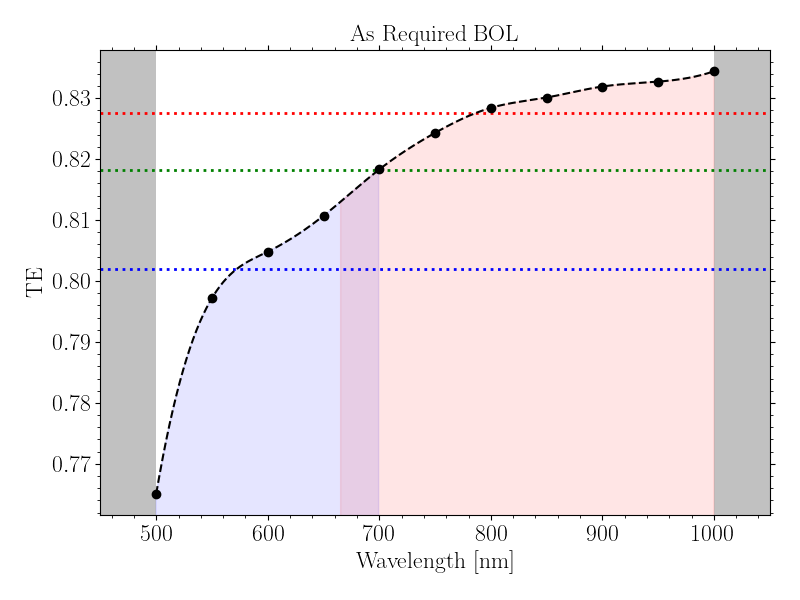

In [11]:
df['TE_Req_BOL_v1'] = estimate_quantity(TE, 'TE', 'Required', 'BOL');

Below is the area under the curve using the optics transmission values from the requirements EOL as computed by Anko (without contamination, without filters).
```
expected output below: 
# 0    0.799907
# 1    0.780122
# 2    0.811549
```

TE: As Required EOL
N-CAM     : 0.799907; Camera/ThroughputLambdaC 750.0; Camera/ThroughputBandwidth 500.0
F-CAM blue: 0.780122; Camera/ThroughputLambdaC 600.2; Camera/ThroughputBandwidth 200.4
F-CAM red : 0.811549; Camera/ThroughputLambdaC 832.7; Camera/ThroughputBandwidth 334.7


<IPython.core.display.Javascript object>


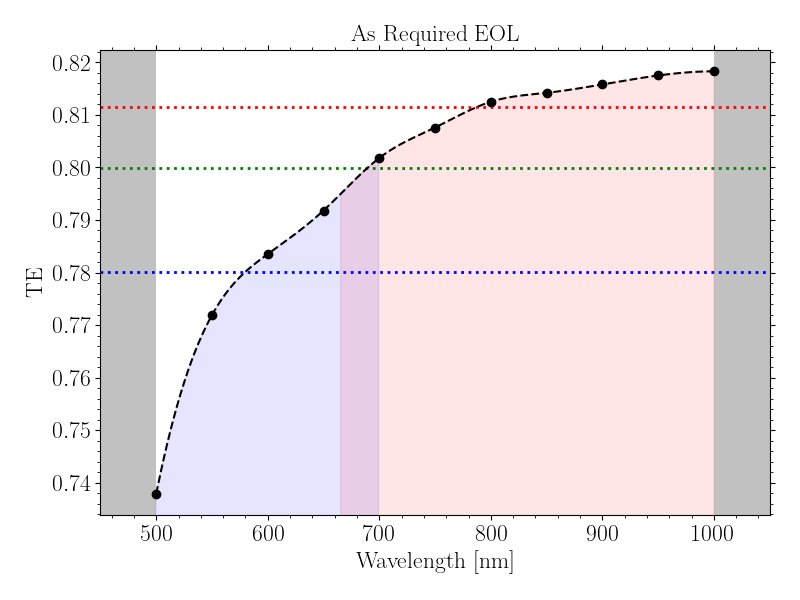

In [12]:
df['TE_Req_EOL_v1'] = estimate_quantity(TE, 'TE', 'Required', 'EOL');

---

In [13]:
# proof of concept of Designed -> expected output below: 0.87
print( f'{0.750 / 0.98 / 0.880:.2f}')
print( f'{0.779 / 0.98 / 0.914:.2f}')

0.87
0.87


TE: As Designed BOL_v2
N-CAM     : 0.870000; Camera/ThroughputLambdaC 750.0; Camera/ThroughputBandwidth 500.0
F-CAM blue: 0.870000; Camera/ThroughputLambdaC 600.2; Camera/ThroughputBandwidth 200.4
F-CAM red : 0.870000; Camera/ThroughputLambdaC 832.7; Camera/ThroughputBandwidth 334.7


<IPython.core.display.Javascript object>


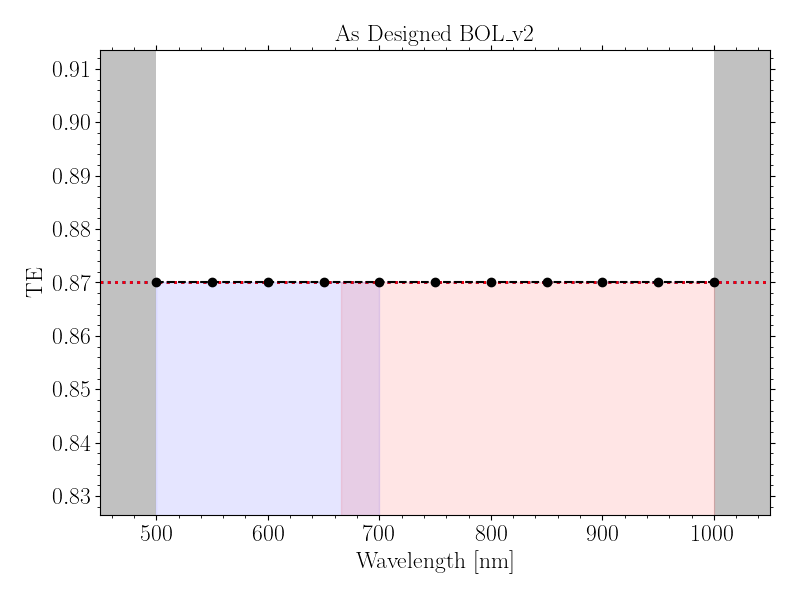

In [14]:
df['TE_Des_v2'] = estimate_quantity(TE_ncam, 'TE', 'Designed', 'BOL_v2');

TE: As Expected BOL_v2
N-CAM     : 0.875225; Camera/ThroughputLambdaC 750.0; Camera/ThroughputBandwidth 500.0
F-CAM blue: 0.859929; Camera/ThroughputLambdaC 600.2; Camera/ThroughputBandwidth 200.4
F-CAM red : 0.883803; Camera/ThroughputLambdaC 832.7; Camera/ThroughputBandwidth 334.7


<IPython.core.display.Javascript object>


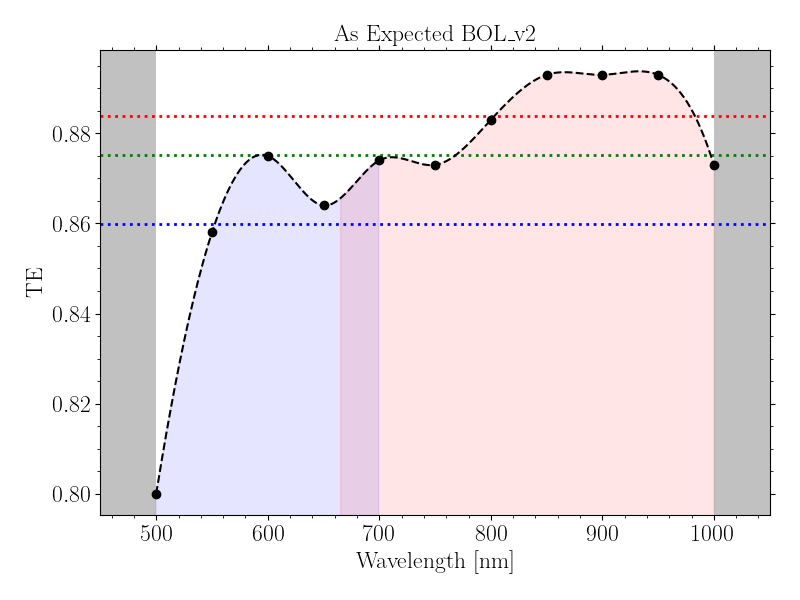

In [15]:
df['TE_Exp_v2'] = estimate_quantity(TE_ncam, 'TE', 'Expected', 'BOL_v2');

TE: As Required BOL_v2
N-CAM     : 0.812541; Camera/ThroughputLambdaC 750.0; Camera/ThroughputBandwidth 500.0
F-CAM blue: 0.797266; Camera/ThroughputLambdaC 600.2; Camera/ThroughputBandwidth 200.4
F-CAM red : 0.821305; Camera/ThroughputLambdaC 832.7; Camera/ThroughputBandwidth 334.7


<IPython.core.display.Javascript object>


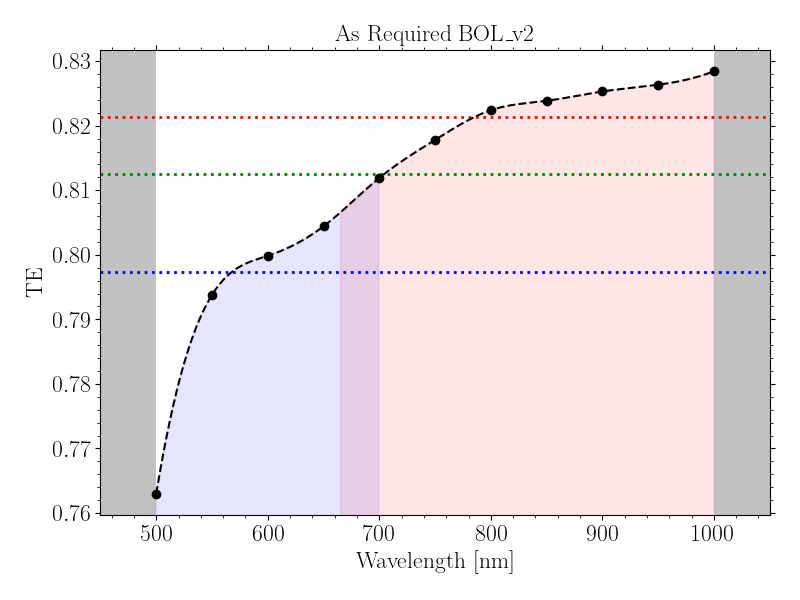

In [16]:
df['TE_Req_BOL_v2'] = estimate_quantity(TE_ncam, 'TE', 'Required', 'BOL_v2');

TE: As Required EOL_v2
N-CAM     : 0.794064; Camera/ThroughputLambdaC 750.0; Camera/ThroughputBandwidth 500.0
F-CAM blue: 0.775061; Camera/ThroughputLambdaC 600.2; Camera/ThroughputBandwidth 200.4
F-CAM red : 0.805147; Camera/ThroughputLambdaC 832.7; Camera/ThroughputBandwidth 334.7


<IPython.core.display.Javascript object>


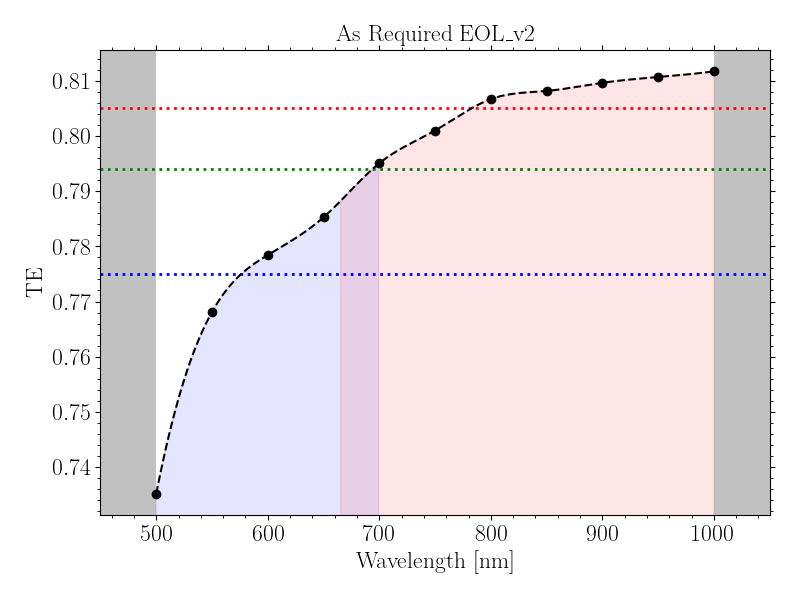

In [17]:
df['TE_Req_EOL_v2'] = estimate_quantity(TE_ncam, 'TE', 'Required', 'EOL_v2');

---

TE: As Designed BOL_v2_blue
F-CAM blue: 0.857820; Camera/ThroughputLambdaC 600.2; Camera/ThroughputBandwidth 200.4


<IPython.core.display.Javascript object>


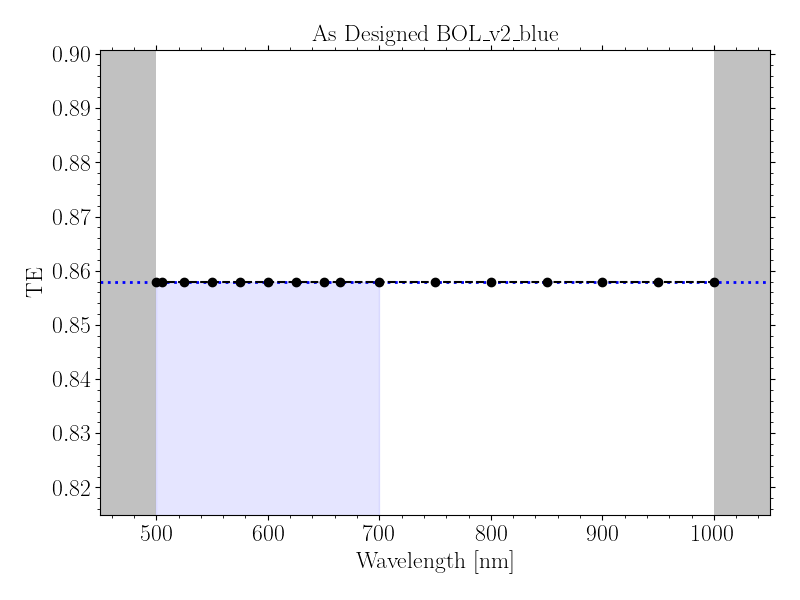

In [18]:
df['TE_Des_v2'].iloc[1] = estimate_quantity(TE_fcam, 'TE', 'Designed', 'BOL_v2_blue', camera='blue')[1];

TE: As Expected BOL_v2_blue
F-CAM blue: 0.656630; Camera/ThroughputLambdaC 585.1; Camera/ThroughputBandwidth 159.7


<IPython.core.display.Javascript object>


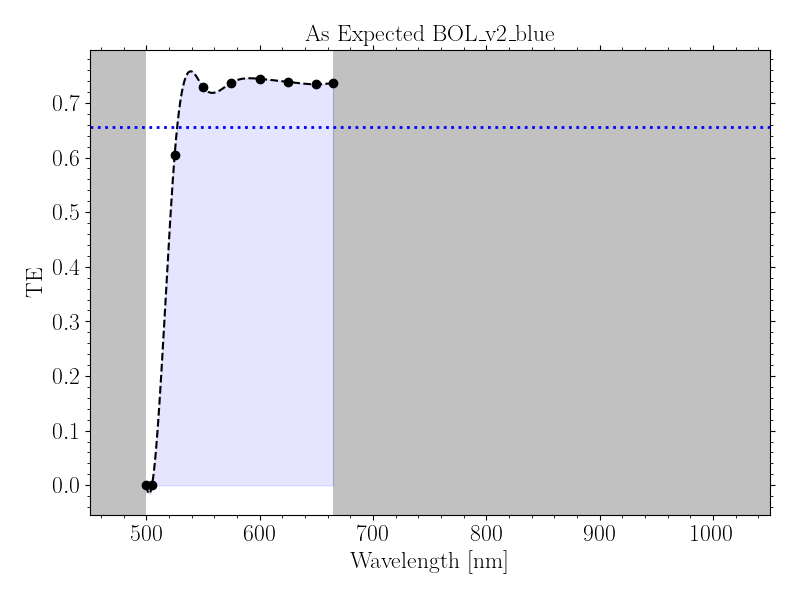

In [19]:
df['TE_Exp_v2'].iloc[1] = estimate_quantity(TE_blue, 'TE', 'Expected', 'BOL_v2_blue', camera='blue')[1];

TE: As Required BOL_v2_blue
F-CAM blue: 0.674514; Camera/ThroughputLambdaC 577.5; Camera/ThroughputBandwidth 145.0


<IPython.core.display.Javascript object>


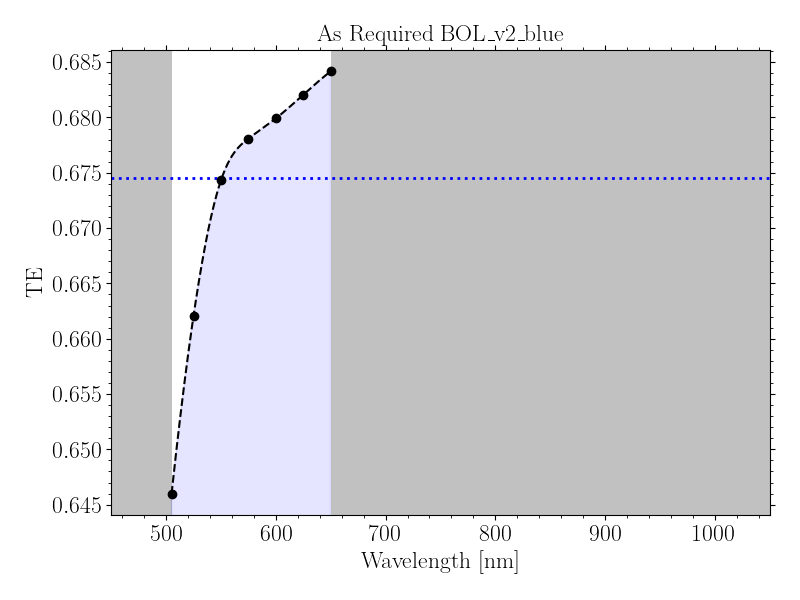

In [20]:
df['TE_Req_BOL_v2'].iloc[1] = estimate_quantity(TE_blue, 'TE', 'Required', 'BOL_v2_blue', camera='blue')[1];

TE: As Required EOL_v2_blue
F-CAM blue: 0.654860; Camera/ThroughputLambdaC 577.5; Camera/ThroughputBandwidth 145.0


<IPython.core.display.Javascript object>


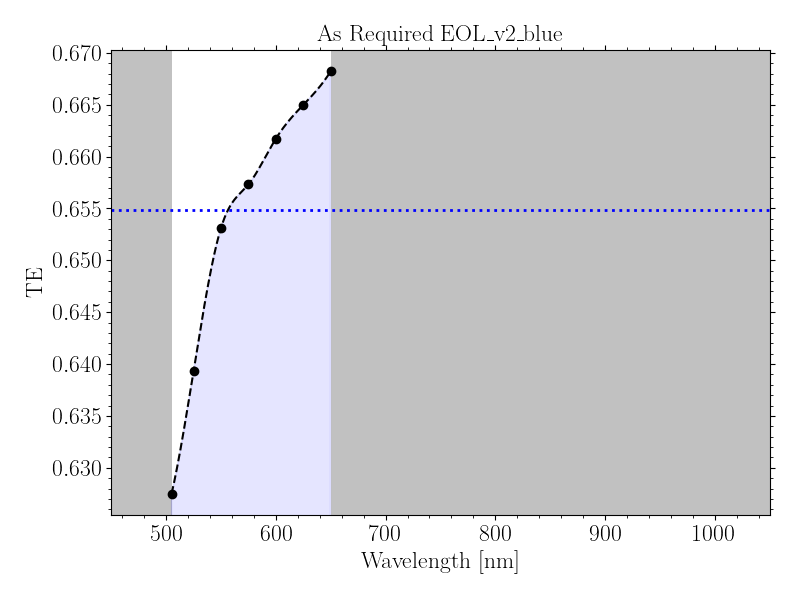

In [21]:
df['TE_Req_EOL_v2'].iloc[1] = estimate_quantity(TE_blue, 'TE', 'Required', 'EOL_v2_blue', camera='blue')[1];

---

TE: As Designed BOL_v2_red
F-CAM red : 0.860430; Camera/ThroughputLambdaC 832.7; Camera/ThroughputBandwidth 334.7


<IPython.core.display.Javascript object>


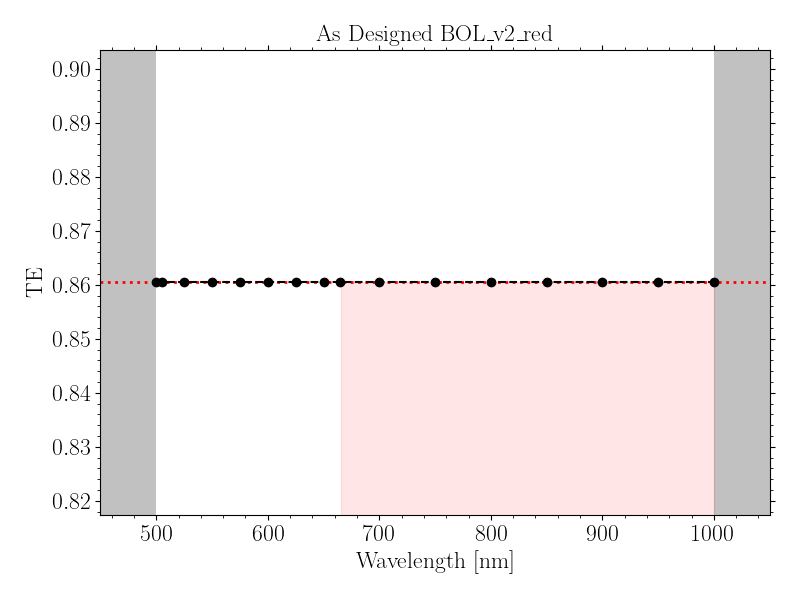

In [22]:
df['TE_Des_v2'].iloc[2] = estimate_quantity(TE_fcam, 'TE', 'Designed', 'BOL_v2_red', camera='red')[2];

TE: As Expected BOL_v2_red
F-CAM red : 0.726647; Camera/ThroughputLambdaC 832.5; Camera/ThroughputBandwidth 335.0


<IPython.core.display.Javascript object>


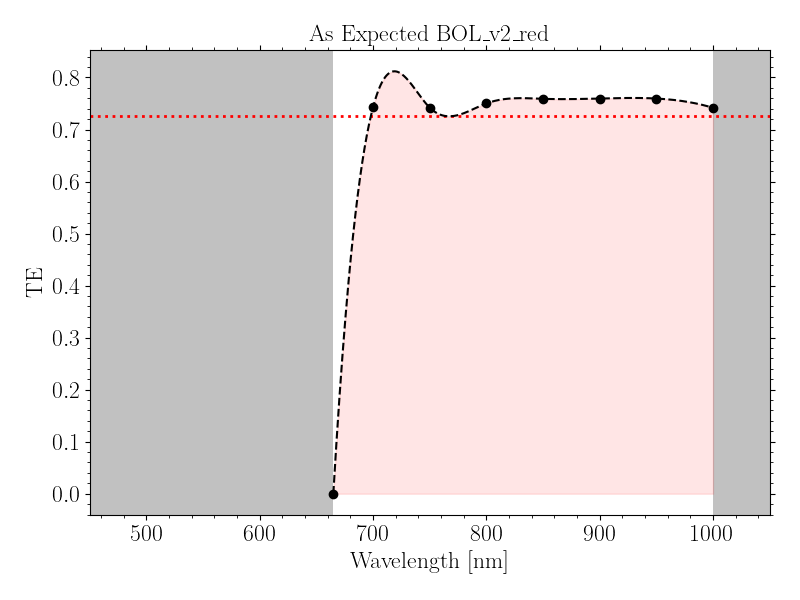

In [23]:
df['TE_Exp_v2'].iloc[2] = estimate_quantity(TE_red, 'TE', 'Expected', 'BOL_v2_red', camera='red')[2];

TE: As Required BOL_v2_red
F-CAM red : 0.697963; Camera/ThroughputLambdaC 832.5; Camera/ThroughputBandwidth 335.0


<IPython.core.display.Javascript object>


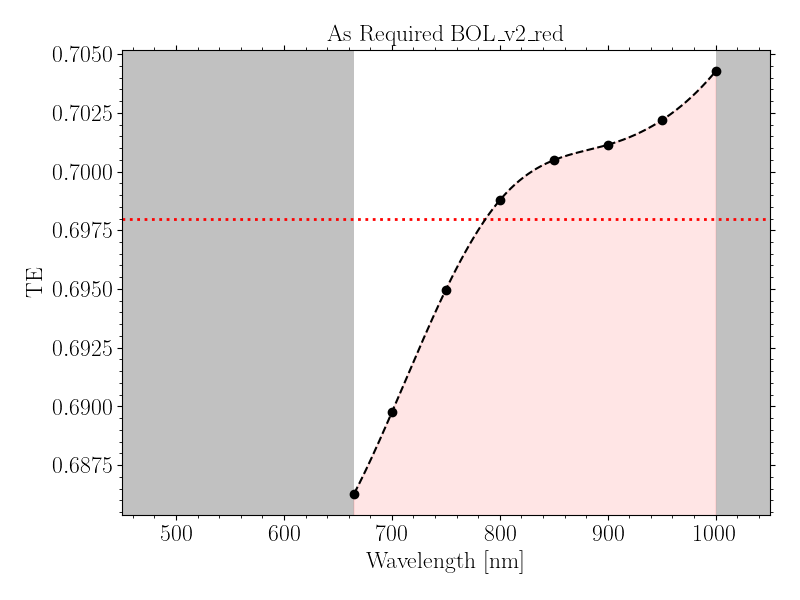

In [24]:
df['TE_Req_BOL_v2'].iloc[2] = estimate_quantity(TE_red, 'TE', 'Required', 'BOL_v2_red', camera='red')[2];

TE: As Required EOL_v2_red
F-CAM red : 0.684477; Camera/ThroughputLambdaC 832.5; Camera/ThroughputBandwidth 335.0


<IPython.core.display.Javascript object>


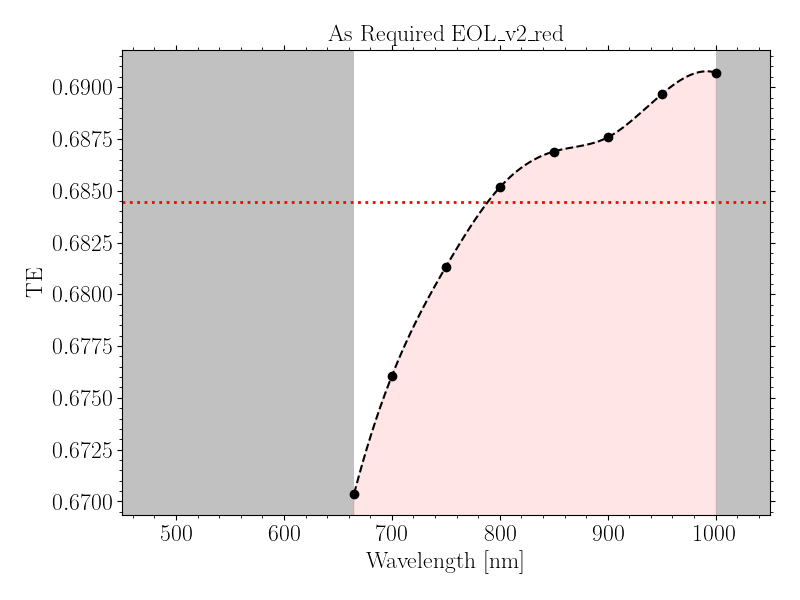

In [25]:
df['TE_Req_EOL_v2'].iloc[2] = estimate_quantity(TE_red, 'TE', 'Required', 'EOL_v2_red', camera='red')[2];

### 3.5. Overview table with results
---


| Required BOL v1 | efficiency | central | width | 
|:--------:|:--------:|:--------:|:--------:|
| N-CAM | 0.8182 | 750 | 500 |
| F-CAM blue | 0.8020 | 600 | 200 |
| F-CAM red | 0.8276 | 833 | 335 |

| Required BOL v2 | efficiency | central | width | 
|:--------:|:--------:|:--------:|:--------:|
| N-CAM | 0.8125 | 750 | 500 |
| F-CAM blue | 0.6745 | 578 | 145 |
| F-CAM red | 0.6980 | 833 | 335 |

| Required EOL v1 | efficiency | central | width | 
|:--------:|:--------:|:--------:|:--------:|
| N-CAM | 0.7999 | 750 | 500 |
| F-CAM blue | 0.7801 | 600 | 200 |
| F-CAM red | 0.8115 | 833 | 335 |

| Required EOL v2 | efficiency | central | width | 
|:--------:|:--------:|:--------:|:--------:|
| N-CAM | 0.7941 | 750 | 500 |
| F-CAM blue | 0.6549 | 578 | 145 |
| F-CAM red | 0.6845 | 833 | 335 |

| Expected | efficiency | central | width | 
|:--------:|:--------:|:--------:|:--------:|
| N-CAM | 0.8752 | 750 | 500 |
| F-CAM blue | 0.6566 | 585 | 165 |
| F-CAM red | 0.7266 | 833 | 335 |

| Designed | efficiency | central | width | 
|:--------:|:--------:|:--------:|:--------:|
| N-CAM | 0.8700 | 750 | 500 |
| F-CAM blue | 0.8578 | 600 | 200 |
| F-CAM red | 0.8604 | 833 | 335 |

---
## 4. TE result comparison
---

We note again that the TE estimate below is solely the optical tranmission (i.e. without MOC and PAC).

In [34]:
# Show data frame with tabulated values calculated above
# 0 stands for N-CAM
# 1 stands for F-CAM blue (though one should be careful)
# 2 stands for F-CAM red (again, careful)
df

,TE_Req_BOL_v1,TE_Req_EOL_v1,TE_Des_v2,TE_Exp_v2,TE_Req_BOL_v2,TE_Req_EOL_v2
0,0.818234,0.799907,0.87000,0.875225,0.812541,0.794064
1,0.802017,0.780122,0.85782,0.656630,0.674514,0.654860
2,0.827633,0.811549,0.86043,0.726647,0.697963,0.684477


### 4.1. Check TE (without contamination)
---

In [39]:
def compute_te_comparison(sim, camera, col):
    
    """This function shows in the screen the comparison of the effective optics
    transmission values between the yaml file in PlatoSim and the values in the
    'df' dictionary that we have generated above
    """
    # Note that v1 is estimates for the N-CAMs since F-CAM measurements were not available at the time.
    # Thus, for the v1 F-CAM estimates, we need to account for the filter transmission of 0.85:
    if camera in ['F-CAM blue', 'F-CAM red']:
        factor = 0.85
    else:
        factor = 1
    
    # Function to calculate ratio
    def percentage(te1, te2, factor):
        return (te1*factor - te2) / te2 * 100
    
    lx = 43
    print(f'PlatoSim {camera} config parameters')
    print('-'*lx)
    print('- TE BOL :', sim["Telescope/TransmissionEfficiency/BOL"])
    print('- TE EOL :', sim["Telescope/TransmissionEfficiency/EOL"])
    print('\nTE "As Required BOL": (v1 - v2) / v2')
    print('-'*lx)
    print(f'{percentage(df["TE_Req_BOL_v1"][col], df["TE_Req_BOL_v2"][col], factor):.4}%')
    print('\nTE "As Required EOL": (v1 - v2) / v2')
    print('-'*lx)
    print(f'{percentage(df["TE_Req_EOL_v1"][col], df["TE_Req_EOL_v2"][col], factor):.4}%')
    print('\nTE "As Required BOL": (PlatoSim - v2) / v2')
    print('-'*lx)
    print(f'{percentage(sim["Telescope/TransmissionEfficiency/BOL"], df["TE_Req_BOL_v2"][col], factor=1):.4}%')
    print('\nTE "As Required EOL": (PlatoSim - v2) / v2')
    print('-'*lx)
    print(f'{percentage(sim["Telescope/TransmissionEfficiency/EOL"], df["TE_Req_EOL_v2"][col], factor=1):.4}%')

#### N-CAMs
---
The comparison between PlatoSim (with the generic YAML configuration) results in comparable values to the transmission efficiencies derived above. The differences between v1 and v2 are minimal, less than 1%, and are not significant. Note that in most of the tables we only have two significant digits. Note also that none of the state-of-the-art measurements done on PLATO hardware reach an accuracy or precission on the transmission values better than few percent.

In [40]:
# Check N-CAM YAML parameters
sim = Simulation('test')
sim.useNormalCamera(performance='required')
compute_te_comparison(sim, 'N-CAM', col=0)

PlatoSim N-CAM config parameters
-------------------------------------------
- TE BOL : 0.8125
- TE EOL : 0.7941

TE "As Required BOL": (v1 - v2) / v2
-------------------------------------------
0.7007%

TE "As Required EOL": (v1 - v2) / v2
-------------------------------------------
0.7359%

TE "As Required BOL": (PlatoSim - v2) / v2
-------------------------------------------
-0.005%

TE "As Required EOL": (PlatoSim - v2) / v2
-------------------------------------------
0.004588%


#### F-CAM blue
---

Here we used to see large differences.

Thing is, the optical train of F-CAM and N-CAM is identical. Therefore, the average TE BOL and EOL of the optics shall be the same as for the N-CAMs: about 81% BOL and 79% EOL in average.

However, the F-CAMs have filters which transmit, per requirement, 85% of the light. So the expected average transmisison of the F-CAM optics is:
- MPDB TE BOL: ( 81% optics) x ( 85% filters) = 69%
- MPDB TE EOL: ( 79% optics) x ( 85% filters) = 67% 

It is worth noting that the measured value of the filter transmission is expected to be around 98% to 99% (see PTO-EST-PL-REP-0952 and comments to the generation of `df` in point 3.3 in this document), so the required 85% is indeed extremely conservative.

In [41]:
# Check F-CAM blue YAM
sim.useFastCamera(passband='blue', performance='required')
compute_te_comparison(sim, 'F-CAM blue', col=1)

PlatoSim F-CAM blue config parameters
-------------------------------------------
- TE BOL : 0.6745
- TE EOL : 0.6549

TE "As Required BOL": (v1 - v2) / v2
-------------------------------------------
1.067%

TE "As Required EOL": (v1 - v2) / v2
-------------------------------------------
1.259%

TE "As Required BOL": (PlatoSim - v2) / v2
-------------------------------------------
-0.002116%

TE "As Required EOL": (PlatoSim - v2) / v2
-------------------------------------------
0.006081%


#### F-CAM red
---

Here we also used to see large differences.

But again, the optical train of F-CAM and N-CAM is identical. Therefore, the average TE BOL and EOL of the optics shall be the same as for the N-CAMs: about 81% BOL and 79% EOL in average.

However, the F-CAMs have filters which transmit, per requirement, 85% of the light. So the expected average transmisison of the F-CAM optics is:
- MPDB TE BOL: ( 81% optics) x ( 85% filters) = 69% 
- MPDB TE EOL: ( 79% optics) x ( 85% filters) = 67% 

It is worth noting that the measured value of the filter transmission is expected to be around 98% to 99% (see PTO-EST-PL-REP-0952 and comments to the generation of `df` in point 3.3 in this document), so the required 85% is indeed extremely conservative.

In [42]:
# Check F-CAM red YAML parameters
sim = Simulation('test')
sim.useFastCamera(passband='red', performance='required')
compute_te_comparison(sim, 'F-CAM red', col=2)

PlatoSim F-CAM red config parameters
-------------------------------------------
- TE BOL : 0.698
- TE EOL : 0.6845

TE "As Required BOL": (v1 - v2) / v2
-------------------------------------------
0.7915%

TE "As Required EOL": (v1 - v2) / v2
-------------------------------------------
0.78%

TE "As Required BOL": (PlatoSim - v2) / v2
-------------------------------------------
0.005254%

TE "As Required EOL": (PlatoSim - v2) / v2
-------------------------------------------
0.003359%


#### Former estimates from simple calculations
---

Below is the simple estimates of the "as required" BOL and EOL, respectively, for both the blue and red filters: 

In [32]:
0.8135*0.85, 0.7945*0.85

(0.691475, 0.675325)

Below is the simple estimates of the "as designed" BOL and EOL, respectively, for both the blue and red filters: 

In [33]:
0.8135*0.97, 0.7945*0.97

(0.789095, 0.7706649999999999)

#### Concluding remarks 
---

- **Nicholas:** after the update in April 2025 we have now consistent configurations in the MPDB and in PlatoSim for the required and designed scenarios for the F-CAMs. The remaining differences below in the 1% level are not significant.

- **Juan 2025-06-03:** TE corresponds to the PlatoSim parameter `Telescope/TransmissionEfficiency/` which is typically fixed in the yaml file. It can also be configured with the function `useFastCameras` from `simulation.py`, as described below. The current configuration in `simulation.py` uses the averaged values above for the TE of F-CAM blue and red. The difference with the MPDB is of few percent, which is in principle acceptable.

### 4.2. Check contamination
---

In [44]:
def show_yaml_response(sim):
    """
    This function shows in the screen the default particulate and molecular 
    contamination efficiency values in PlatoSim.
    """
    print('- Par. contamination : ', sim["CCD/Contamination/ParticulateContaminationEfficiency"])
    print('- Mol. contamination : ', sim["CCD/Contamination/MolecularContaminationEfficiency"])
    print('- CCD polarization   : ', sim["CCD/Polarization/ExpectedValue"])
    print('- CCD QE             : ', sim["CCD/QuantumEfficiency/MeanQuantumEfficiency"])

In [45]:
# PlatoSim values
# Note that MOC should be time dependent but is not modelled as such yet in PlatoSim.
show_yaml_response(sim)

- Par. contamination :  0.972
- Mol. contamination :  0.9573
- CCD polarization   :  0.989
- CCD QE             :  0.5184


In [46]:
# Combined MOC and PAC contamination from v2:
df_ncam['moc'].mean() * df_ncam['pac'].mean()

0.9382163636363636

TE: As moc v2
N-CAM     : 0.960281; Camera/ThroughputLambdaC 750.0; Camera/ThroughputBandwidth 500.0
F-CAM blue: 0.937584; Camera/ThroughputLambdaC 600.2; Camera/ThroughputBandwidth 200.4
F-CAM red : 0.974310; Camera/ThroughputLambdaC 832.7; Camera/ThroughputBandwidth 334.7


<IPython.core.display.Javascript object>


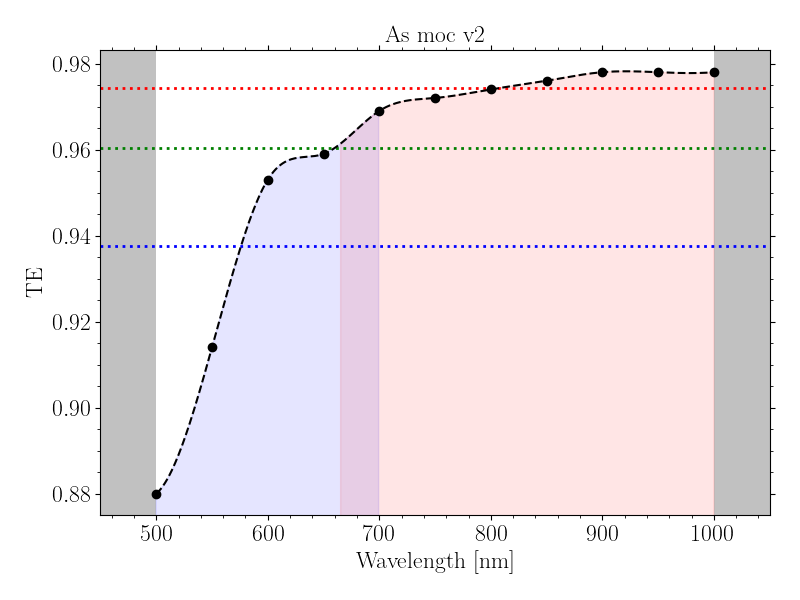

In [11]:
# Estimate the MOC from v2
TE_ncam['TE_moc_v2'] = df_ncam['moc'].to_numpy()
estimate_quantity(TE_ncam, 'TE', 'moc', 'v2');

In [47]:
# As measured transmission values for F-CAMs (PTO-EST-PL-REP-0952)
TE_fil_FCAM_blue = 0.986
TE_fil_FCAM_red  = 0.989

# Print blue and red filter values used in PlatoSim
print(' '*5 + 'Blue'+' '*15 + 'Red')
print('-'*42)
print('BOL:', 
      df['TE_Req_BOL_v2'][1] * TE_fil_FCAM_blue, 
      df['TE_Req_BOL_v2'][2] * TE_fil_FCAM_red)
print('EOL:', 
      df['TE_Req_EOL_v2'][1] * TE_fil_FCAM_blue, 
      df['TE_Req_EOL_v2'][2] * TE_fil_FCAM_red)

     Blue               Red
------------------------------------------
BOL: 0.6650710720929469 0.6902857337640794
EOL: 0.6456921357129485 0.6769477622187248


---
## 5. Quantum efficiency
---

The Quantum Efficiency (QE) is the same for all CCDs, i.e. independent of:
- camera (N-CAM and F-CAM)
- time (BOL and EOL)

Note the QE does depend on the incident angle, but not yet implemented in PlatoSim.

### 5.1. QE tabulations from the MPDB (frozen v.4) 
---


In [48]:
# Interpolate data with cubic spline
# The required  values defined below are indeed those in PL-SYS-374, 
# The 'designed' values defined below are not those in the MPDB. The scenarios included in the MPDB are
# described in detail in PTO-EST-PL-RP-0936 (see Table 4). The 'designed' values below correspond to the
# average QE of the frame-transfer CCDs (ignoring the full-frame CCDs) in PTO-E2V-CCD-DP-1114v6. These
# are only representative for the F-CAMs, not for the N-CAMs and we prefer, at system level, to use the 
# values in PTO-EST-PL-RP-0936. However, the difference is minimal.
# We have introduced the 'simulated' values as per PLATO-DLR-PL-HO-0014, see Table 4, column 'mean QE' in 
# PLATO-EST-PL-REP-0936 issue 2.0.
QE = {'wl' : np.array([500, 600, 700, 800, 900, 950, 1000]),
      'QE_Required_BOL'  : np.array([0.737, 0.877, 0.858, 0.655, 0.314, 0.165, 0.062]),
      'QE_Designed_BOL'  : np.array([0.826, 0.923, 0.873, 0.664, 0.335, 0.188, 0.082]),
      'QE_Simulated_BOL' : np.array([0.817, 0.923, 0.875, 0.657, 0.339, 0.190, 0.082])
     }

QE: As Required BOL
N-CAM     : 0.626676; Camera/ThroughputLambdaC 750.0; Camera/ThroughputBandwidth 500.0
F-CAM blue: 0.850475; Camera/ThroughputLambdaC 600.2; Camera/ThroughputBandwidth 200.4
F-CAM red : 0.518443; Camera/ThroughputLambdaC 832.7; Camera/ThroughputBandwidth 334.7


<IPython.core.display.Javascript object>


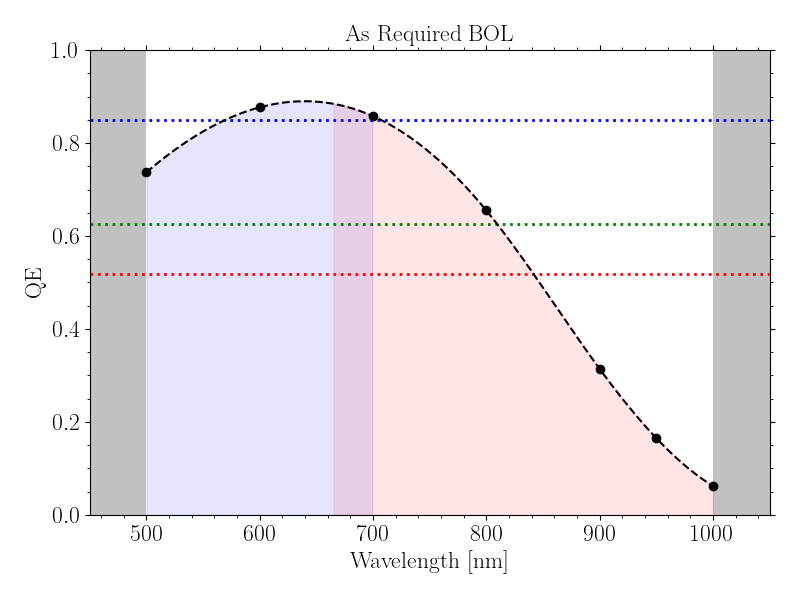

In [49]:
QE_Required_BOL = estimate_quantity(QE, 'QE', 'Required', 'BOL');

QE: As Designed BOL
N-CAM     : 0.655230; Camera/ThroughputLambdaC 750.0; Camera/ThroughputBandwidth 500.0
F-CAM blue: 0.898574; Camera/ThroughputLambdaC 600.2; Camera/ThroughputBandwidth 200.4
F-CAM red : 0.534379; Camera/ThroughputLambdaC 832.7; Camera/ThroughputBandwidth 334.7


<IPython.core.display.Javascript object>


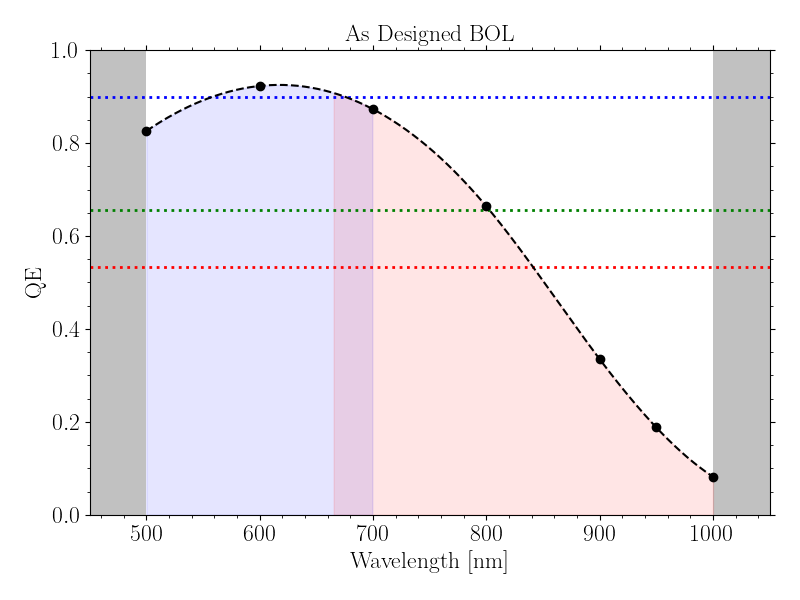

In [50]:
QE_Designed_BOL = estimate_quantity(QE, 'QE', 'Designed', 'BOL');

QE: As Simulated BOL
N-CAM     : 0.654167; Camera/ThroughputLambdaC 750.0; Camera/ThroughputBandwidth 500.0
F-CAM blue: 0.897398; Camera/ThroughputLambdaC 600.2; Camera/ThroughputBandwidth 200.4
F-CAM red : 0.533789; Camera/ThroughputLambdaC 832.7; Camera/ThroughputBandwidth 334.7


<IPython.core.display.Javascript object>


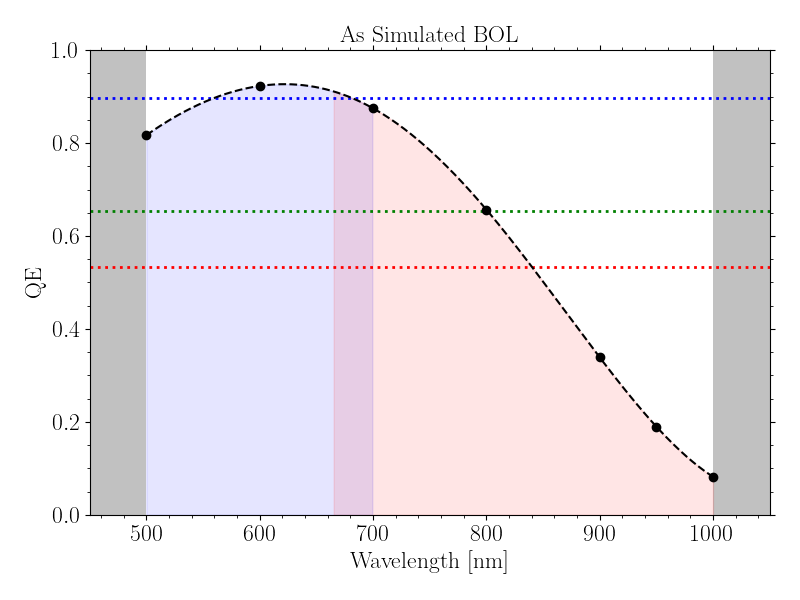

In [51]:
QE_Simulated_BOL = estimate_quantity(QE, 'QE', 'Simulated', 'BOL');

---
## 6. Absolute spectral response
---

We here look at the absolute spectral response for the "As Required" tabulated values.

By interpolating to the same wavelength range the transmission efficiencies `TE` and the quantum efficiencies `QE` we can compute the effective camera throughputs. Don't forget to add the contribution of MOC and PAC where appropriate.

In [52]:
def estimate_response(dictionary, quantity, performance='Required', time='BOL'):

    """This function takes as input a dictionary of transmission efficiency (TE)
    or quantum efficiency values (QE) and makes an interpolation across wavelength. 
    The behaviour is the same as the first half of the function estimate_quantity() above.
    """
    
    # Select columns
    wl = dictionary['wl']
    xx = dictionary[f'{quantity}_{performance}_{time}']
    
    # Remove NaN rows
    dex_nan = np.isnan(xx)
    wl = wl[~dex_nan]
    xx = xx[~dex_nan]
    
    # Interpolate data
    grid_no = 500
    wl_int = np.linspace(wl[0], wl[-1], grid_no)                                                                                                                                         
    spline = scipy.interpolate.make_interp_spline(wl, xx, k=3)                                                                                                                                             
    xx_int = spline(wl_int)
    
    return wl_int, xx_int

In [53]:
def estimate_absolute_response(wl_int, xx_int, performance='Required', time='BOL', 
                               camera='all', plot=True):
    
    """This function takes as input an interpolated pair of wavelenght
    and values generated with estimate_response() and makes an integrates
    the area below the curve. The behaviour is the same as the second half
    of the function estimate_quantity() above.
    """
    print(f'Spectral response "As {performance} {time}"')
    
    # Find wavelenght averages
    dex_665 = ut.findNearestIndex(wl_int, 665)
    dex_700 = ut.findNearestIndex(wl_int, 700)
    
    if camera in ['all', 'ncam']:
        xx_NCAM = np.trapz(xx_int / (len(wl_int) - 1))
        print(f"N-CAM      : {xx_NCAM:.4f}")
    else: 
        xx_NCAM = None
        
    if camera in ['all', 'blue']:
        xx_FCAM_blue = np.trapz(xx_int[:dex_700] / (len(wl_int[:dex_700]) - 1))
        print(f"F-CAM blue : {xx_FCAM_blue:.4f}")
    else: 
        xx_FCAM_blue = None
        
    if camera in ['all', 'red']:
        xx_FCAM_red  = np.trapz(xx_int[dex_665:] / (len(wl_int[dex_665:]) - 1))
        print(f"F-CAM red  : {xx_FCAM_red:.4f}")
    else: 
        xx_FCAM_red = None

    # Plot figure
    if plot:
        xlim = [450, 1050]
        fig = plt.figure(figsize=(8,6))
        plt.axvspan(xlim[0], wl[0],  facecolor='0.2', alpha=0.3)
        plt.axvspan(wl[-1], xlim[1], facecolor='0.2', alpha=0.3)
        if camera in ['all', 'ncam']:
            plt.axhline(y=xx_NCAM, color='g', linestyle=':', linewidth=2, label = "N-CAM")
        if camera in ['all', 'blue']:
            plt.fill_between(wl_int[:dex_700], xx_int[:dex_700], color='blue', alpha=.1)
            plt.axhline(y=xx_FCAM_blue, color='b', linestyle=':', linewidth=2, label = "F-CAM blue")
        if camera in ['all', 'red']:
            plt.fill_between(wl_int[dex_665:], xx_int[dex_665:], color='red',  alpha=.1)
            plt.axhline(y=xx_FCAM_red,  color='r', linestyle=':', linewidth=2, label = "F-CAM red")
        plt.plot(wl_int, xx_int, 'k--')
        plt.title(f"As {performance} {time}")
        plt.xlabel("Wavelength [nm]")
        plt.ylabel("Absolute spectral response")
        plt.xlim(xlim)
        plt.ylim(0, 1)
        plt.tight_layout();

    return xx_NCAM, xx_FCAM_blue, xx_FCAM_red

Spectral response "As Designed BOL"
N-CAM      : 0.5701
F-CAM blue : 0.7818
F-CAM red  : 0.4649


<IPython.core.display.Javascript object>


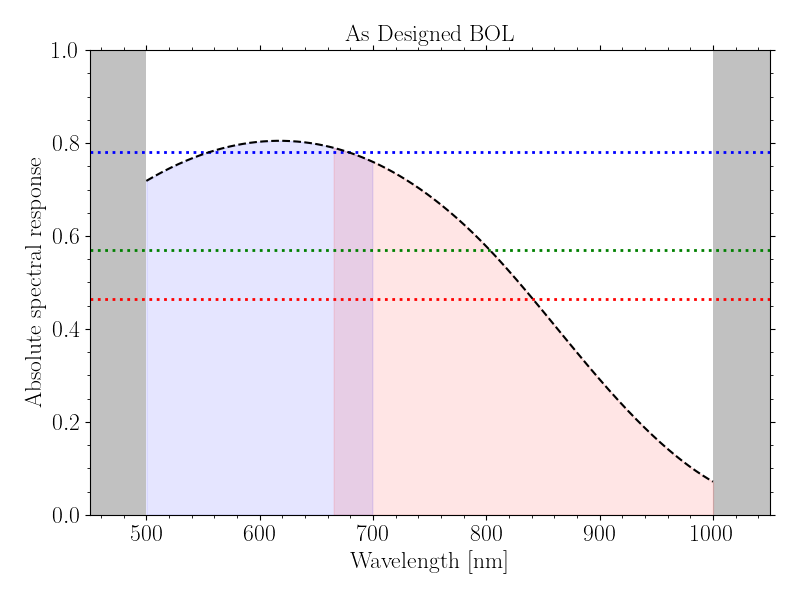

In [54]:
# Calculate the Absolute Spectral Response (ASR) "As Designed BOL"
te = estimate_response(TE_ncam, 'TE', 'Designed', 'BOL_v2')
qe = estimate_response(QE, 'QE', 'Designed', 'BOL')
wl = qe[0]
ASR = te[1] * qe[1]
estimate_absolute_response(wl, ASR, 'Designed', 'BOL');

Spectral response "As Required BOL"
N-CAM      : 0.4944
F-CAM blue : 0.6597
F-CAM red  : 0.4159


<IPython.core.display.Javascript object>


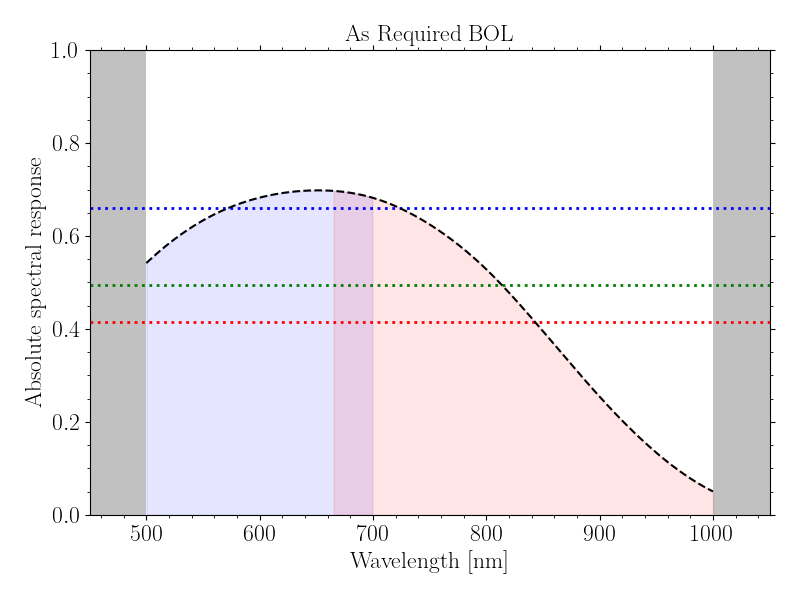

In [55]:
# Calculate the Absolute Spectral Response (ASR) "As Required BOL"
te = estimate_response(TE_ncam, 'TE', 'Required', 'EOL_v2')
qe = estimate_response(QE, 'QE', 'Required', 'BOL')
wl = qe[0]
ASR = te[1] * qe[1]
estimate_absolute_response(wl, ASR, 'Required', 'BOL');

### 6.1. Compare with PlatoSim YAML parameters
---

In [56]:
def compute_response(sim):
    """This function displays the default PlatoSim configuration values 
    for different efficiency factors.
    """
    lx = 40
    trans = (sim["CCD/Contamination/ParticulateContaminationEfficiency"] *
             sim["CCD/Contamination/MolecularContaminationEfficiency"] *
             sim["CCD/Polarization/ExpectedValue"] * 
             sim["CCD/QuantumEfficiency/MeanQuantumEfficiency"])
    total_BOL = sim["Telescope/TransmissionEfficiency/BOL"] * trans
    total_EOL = sim["Telescope/TransmissionEfficiency/EOL"] * trans
    
    print('Absolute spectral response')
    print('-'*lx)
    print('- TE BOL             : ', sim["Telescope/TransmissionEfficiency/BOL"])
    print('- TE EOL             : ', sim["Telescope/TransmissionEfficiency/EOL"])
    print('- Par. contamination : ', sim["CCD/Contamination/ParticulateContaminationEfficiency"])
    print('- Mol. contamination : ', sim["CCD/Contamination/MolecularContaminationEfficiency"])
    print('- CCD polarization   : ', sim["CCD/Polarization/ExpectedValue"])
    print('- CCD QE             : ', sim["CCD/QuantumEfficiency/MeanQuantumEfficiency"])
    print('-'*lx)
    print(f'Absolute spectral response BOL : {total_BOL:.4f}')
    print(f'Absolute spectral response EOL : {total_EOL:.4f}')

#### N-CAMs

The average `TE` BOL and EOL have already been discussed above (see 4.1 in this document) and they are consistent between PlatoSim and MPDB.

The average particulate contamination (PAC) is about 98% in the MPDB, close to the the PlatoSim value below.

The average particulate contamination (MOC) is about 96% in the MPDB, close to the PlatoSim value below.

Polarization is not discussed in the MPDB, but see PLATO-DLR-PL-RP-0001 (chapter 4.2.5.2), which indeed considers an average value of 0.989.

The average required QE is consistent with the MPDB values.

In [57]:
# N-CAM spectral response at BOL (without vignetting)
sim = Simulation('test')
sim.useNormalCamera(performance='required')
compute_response(sim)

Absolute spectral response
----------------------------------------
- TE BOL             :  0.8125
- TE EOL             :  0.7941
- Par. contamination :  0.972
- Mol. contamination :  0.9573
- CCD polarization   :  0.989
- CCD QE             :  0.6267
----------------------------------------
Absolute spectral response BOL : 0.4686
Absolute spectral response EOL : 0.4580


#### F-CAMb

The average TE BOL and EOL have already been discussed above (see 4.1 in this document) and the previously found discrepancies between PlatoSim and MPDB are understood.

The average particulate contamination (PAC) is about 98% in the MPDB, close to the the PlatoSim value below.

The average particulate contamination (MOC) is about 96% in the MPDB, close to the PlatoSim value below.

Polarization is not discussed in the MPDB, but see PLATO-DLR-PL-RP-0001 (chapter 4.2.5.2), which indeed considers an average value of 0.989.

The average required QE is consistent with the MPDB values.

In [58]:
# F-CAM blue spectral response (without vignetting)
sim = Simulation('test')
sim.useFastCamera(passband='blue', performance='required')
compute_response(sim)

Absolute spectral response
----------------------------------------
- TE BOL             :  0.6745
- TE EOL             :  0.6549
- Par. contamination :  0.972
- Mol. contamination :  0.9573
- CCD polarization   :  0.989
- CCD QE             :  0.8505
----------------------------------------
Absolute spectral response BOL : 0.5279
Absolute spectral response EOL : 0.5126


#### F-CAMr

The average TE BOL and EOL have already been discussed above (see 4.1 in this document) and the previously found discrepancies between PlatoSim and MPDB are understood.

The average particulate contamination (PAC) is about 98% in the MPDB, close to the the PlatoSim value below.

The average particulate contamination (MOC) is about 96% in the MPDB, close to the PlatoSim value below.

Polarization is not discussed in the MPDB, but see PLATO-DLR-PL-RP-0001 (chapter 4.2.5.2), which indeed considers an average value of 0.989.

The average required QE is consistent with the MPDB values.

In [59]:
# F-CAM red spectral response (without vignetting)
sim = Simulation('test')
sim.useFastCamera(passband='red', performance='required')
compute_response(sim)

Absolute spectral response
----------------------------------------
- TE BOL             :  0.698
- TE EOL             :  0.6845
- Par. contamination :  0.972
- Mol. contamination :  0.9573
- CCD polarization   :  0.989
- CCD QE             :  0.5184
----------------------------------------
Absolute spectral response BOL : 0.3330
Absolute spectral response EOL : 0.3265


---
## 7. Test zero-point fluxes
---

    # comment by R. Samadi (https://github.com/IvS-KULeuven/PlatoSim3/issues/1043):
    #  The value of Fluxm0 = 0.73244782244e8 is not directly taken from Marchiori et al (2019.
    #  The original value used by platosim was 1.00179e8
    #  This was so far their definition of the zero point for a V=0 star
    #  Now according to Marchiori et al (2019), the difference btw V and P magnitude (as defined in Marchiori et al) is 0.34
    #  We have change 1.00179e8 by the factor 10^(-0.4*0.34) = 0.7311390834834174
    #  hence the value of Fluxm0 = 0.73244782244e8
    # 
    # Now, checking equation 7 and Table 6 in Marchiori et al. (2019) we expect 
    #  f_p = 10^{-0.4*(P-z_P)} with z_P = 20.62, hence f_p = 1.77e8 e-/s, so I 
    # cannot immediately reproduce the value quoted by R. Samadi in the comment above.
    # The 1.77e8 e-/s is consistent with the 1.43e8 at V = 8 (P = 7.66) in Table 5
    # of Marchiori et al. (2019) if one does not forget the contribution of vignetting.
    #
    # Indeed, as Reza points out, PlatoSim uses V magnitude as reference, so 
    # one has to change the reference value f_p to the fainter V magnitude 
    # (P = 0 is V = -0.34; so P = 0.34 is V = 0). 
    # However, Marchiori et al. (2019) only computed the V - P = -0.34 for the N-CAMs.
    # In PLATO-UPD-SCI-TN-0009 we also computed th V - P for the F-CAMs and they
    # turn out to be very different from the N-CAMs. So the assumption below that
    # the zero point flux is the same for N-CAMs and F-CAMs is not correct.
    # We should refer here to tables 4 and 5 in PLATO-DLR-PL-TN-0113.
    # For reference, the zero point by PLATO-UPD-SCI-TN-0009 for the N-CAMs is 20.78
    # while it is 20.19 and 19.81 for the F-CAM blue and F-CAM red respectively.
    # This means that at magnitude V = 0 we expect N-CAMs to collect 73% of the 
    # flux of a P = 0 star; but the F-CAM blue will collect only 58% (F-CAM blue/N-CAM = 80%)
    # and the F-CAM red only 41% (F-CAM red/N-CAM = 56%).
    # A lot of this difference (80% vs 56%) is due to the extremely conservative
    # construction of the F-CAM magnitude (see PLATO-DLR-PL-TN-0113) that we definitely
    # need to review at system level.

In [63]:
# Working directory (update as needed)
workDir = Path('/lhome/nicholas/software/workdir/DLR113')
# workDir = Path('/lcl/lro3/epa_bowl_sa/platosim/spectral_response')

# The configurations
inputFile = Path(os.getenv('PLATO_PROJECT_HOME')) / 'inputfiles/inputfile.yaml'

# performance for the simulations
performance = 'required'
passband    = 'Vmag'

In [64]:
# The PLATO magnitudes (Pmag) and corresponding fluxes are taken from PLATO-DLR-PL-TN-0113
cfgs = [{'cam'        : 'N-CAMs' , 
         'cfg_file'   : 'inputfile_ncam.yaml',
         'output_dir' : workDir / 'ncam',
         'Vmag'       : np.array([8, 9, 10, 11, 12, 13]),
         'Pmag'       : np.array([7.62, 8.62, 9.62, 10.62, 11.62, 12.62]),
         'flux_simulate_BOL' : np.array([1.84e5, 7.31e4, 2.91e4, 1.16e4, 4.62e3, 1.84e3]),
         'flux_required_BOL' : np.array([1.62e5, 6.44e4, 2.56e4, 1.02e4, 4.06e3, 1.62e3]),
         'flux_required_EOL' : np.array([1.58e5, 6.27e4, 2.50e4, 9.94e3, 3.96e3, 1.58e3]),
        },
        {'cam'        : 'F-CAMb', 
         'cfg_file'   : 'inputfile_fcamb.yaml',
         'output_dir' : workDir / 'fcamb',
         'Vmag'       : np.array([8, 9, 10, 11, 12, 13]),
         'Pmag'       : np.array( [ 7.88, 8.88, 9.88, 10.88, 11.88, 12.88]),
         'flux_simulate_BOL' : np.array([8.38e4, 3.33e4, 1.33e4, 5.28e3, 2.10e3, 8.38e2]),
         'flux_required_BOL' : np.array([6.58e4, 2.62e4, 1.04e4, 4.15e3, 1.65e3, 6.58e2]),
         'flux_required_EOL' : np.array([6.39e4, 2.54e4, 1.01e4, 4.03e3, 1.61e3, 6.39e2]),
        },
        {'cam'        : 'F-CAMr', 
         'cfg_file'   : 'inputfile_fcamr.yaml', 
         'output_dir' : workDir / 'fcamr',
         'Vmag'       : np.array([8, 9, 10, 11, 12, 13]),
         'Pmag'       : np.array( [ 7.40, 8.40, 9.40, 10.40, 11.40, 12.40]),
         'flux_simulate_BOL' : np.array([9.17e4, 3.65e4, 1.45e4, 5.78e3, 2.30e3, 9.17e2]),
         'flux_required_BOL' : np.array([7.41e4, 2.95e4, 1.17e4, 4.68e3, 1.86e3, 7.41e2]),
         'flux_required_EOL' : np.array([7.27e4, 2.89e4, 1.15e4, 4.58e3, 1.83e3, 7.27e2]),
         }]

In [65]:
# Here we generate baseline configuration files using the tools implemented by PlatoSim.
# These files serve as the base input to PlatoSim.
for cfg in cfgs:
    
    # we will output the yaml configuration file here
    cfg_file = cfg['output_dir'] / cfg['cfg_file']
    
    # Create output directory for each sim
    path = Path(cfg['output_dir'])
    if not path.is_dir():
        path.mkdir(parents=True, exist_ok=True)
        
    # we call PlatoSim
    cfg['psim'] = Simulation(cfg['cam'])
    
    # We adjust the reference flux to that of the PLATO passband
    if passband == 'Pmag':
        cfg['psim']['ObservingParameters/Fluxm0'] = 0.73244782244e8
    
    # We generate the default configurations
    if cfg['cam'] == 'N-CAMs':
        cfg['psim'].useNormalCamera(performance=performance)
    elif cfg['cam'] == 'F-CAMb':
        cfg['psim'].useFastCamera(passband='blue', performance=performance)
    elif cfg['cam'] == 'F-CAMr':
        cfg['psim'].useFastCamera(passband='red', performance=performance)
    else:
        print('### error configuring camera ###')
        break
    
    # Simulate N exposure to average random noise
    cfg['psim']["ObservingParameters/NumExposures"] = 100
    
    # Disable cosmic rays to avoid large spurious counts
    cfg['psim']['Sky/IncludeCosmicsInSubField']    = 'no'
    cfg['psim']['Sky/IncludeCosmicsInSmearingMap'] = 'no'
    cfg['psim']['Sky/IncludeCosmicsInBiasMap']     = 'no'
    
    # Disable vignetting since we compare to unvignetted values
    cfg['psim']['CCD/IncludeRelativeTransmissivity'] = 'no'
        
    # we output the default configurations to the yaml files
    cfg['psim'].writeYamlConfigurationFile(cfg_file)
    
    # produce some output
    print('-'*50)
    print('Yaml configuration file for', cfg['cam'], 'printed to', cfg['cfg_file'])
    value = cfg['psim'][ "ObservingParameters/Fluxm0"]
    print('- reference flux     : ', f'{value:.2e}', '[phot/s/m^2/nm]')
    print('- central wavelength : ', cfg['psim'][ "Camera/ThroughputLambdaC"], 'nm')
    print('- bandwith           : ', cfg['psim'][ "Camera/ThroughputBandwidth"], 'nm')
    print('- BOL efficiency     : ', cfg['psim'][ "Telescope/TransmissionEfficiency/BOL"])
    print('- EOL efficiency     : ', cfg['psim'][ "Telescope/TransmissionEfficiency/EOL"])
    print('- mean CCD QE        : ', cfg['psim'][ "CCD/QuantumEfficiency/MeanQuantumEfficiency"])
    print('- telescope group    : ', cfg['psim'][ "Telescope/GroupID"])
    print('- cycle time         : ', cfg['psim'][ "ObservingParameters/CycleTime"], 's')
    print('- readout time       : ', cfg['psim'].getReadoutTime(), 's')

--------------------------------------------------
Yaml configuration file for N-CAMs printed to inputfile_ncam.yaml
- reference flux     :  1.00e+08 [phot/s/m^2/nm]
- central wavelength :  750 nm
- bandwith           :  500 nm
- BOL efficiency     :  0.8125
- EOL efficiency     :  0.7941
- mean CCD QE        :  0.6267
- telescope group    :  Custom
- cycle time         :  25 s
- readout time       :  (4.003372000000001, 0) s
--------------------------------------------------
Yaml configuration file for F-CAMb printed to inputfile_fcamb.yaml
- reference flux     :  1.00e+08 [phot/s/m^2/nm]
- central wavelength :  578 nm
- bandwith           :  145 nm
- BOL efficiency     :  0.6745
- EOL efficiency     :  0.6549
- mean CCD QE        :  0.8505
- telescope group    :  Fast
- cycle time         :  2.5 s
- readout time       :  (0.20295, 0.026454000000000002) s
--------------------------------------------------
Yaml configuration file for F-CAMr printed to inputfile_fcamr.yaml
- reference f

In [108]:
# General table of values from Section 3.5:
#                central wavelength           bandwith
#              PlatoSim  this document  PlatoSim  this document
# N-CAM             550            750       532            500
# F-CAM blue        600            578       165            145
# F-CAM red         832            833       335            335
#
# NOTE: the PlatoSim values has been changed in simulation.py to the values of this document for further calculation.

In [66]:
def compare_results(cfgs, flux_table):
    """
    This function compares the zero-point fluxes [e-/s] between PlatoSim
    and the values tabulated in PLATO-DLR-PL-TN-0113.
    """
    
    # the units should be consistent
    for cfg in cfgs:
        data = {passband:cfg[passband], 
                'tabulated_flux':cfg[flux_table], 
                'platosim_flux':cfg['flux']}
        df = pd.DataFrame(data=data)
        output_file_name = cfg['output_dir'] / f'{cfg["cam"]}_spectral_response.csv'
        df.to_csv(output_file_name, index = False)

    # Pack flux estimates
    flux0 = np.array((cfgs[0]['flux'] / cfgs[0][flux_table], 
                      cfgs[1]['flux'] / cfgs[1][flux_table], 
                      cfgs[2]['flux'] / cfgs[2][flux_table])).T
    
    # Plot residuals
    fig, ax = plt.subplots(1, 1, figsize=(8,5))
    ax.plot(cfgs[0]['Vmag'], np.ones(len(cfgs[0]['Vmag'])), 'k:', zorder=1)
    ax.plot(cfgs[0]['Vmag'], flux0[:,0], 'o--', c='g', zorder=2)
    ax.plot(cfgs[0]['Vmag'], flux0[:,1], 'o--', c='b', zorder=2)
    ax.plot(cfgs[0]['Vmag'], flux0[:,2], 'o--', c='r', zorder=2)
    ax.set_xlabel('V-band magnitude')
    ax.set_ylabel('Flux ratio (PlatoSim / DLR-TN-113)')
    plt.tight_layout();
    
    return flux0

### 7.1. Use built-in on-board photometry module of PlatoSim
---

In [67]:
# Here we extract the fluxes simulated with PlatoSim and compare with the tabulated values
for cfg in cfgs:
    cfg['flux'] = []
    v = cfg['Vmag']
    
    # Run for all magnitudes
    for i in tqdm(range(len(v)), bar_format=ut.tqdmBar(), desc=cfg['cam']):
        
        # Configure simulation
        outputFileName = cfg['cam'] + '_' + str(v[i])
        cfg_file = cfg['output_dir'] / cfg['cfg_file']
        cfg['psim'] = Simulation(outputFileName, configurationFile=cfg_file, outputDir=path)
        
        # Set up out subfield
        dim = 8
        cfg['psim']["SubField/ZeroPointRow"]    = 3000
        cfg['psim']["SubField/ZeroPointColumn"] = 3000
        cfg['psim']["SubField/NumColumns"]      = dim
        cfg['psim']["SubField/NumRows"]         = dim
    
        # My PlatoSim doesn't like this to be set to 'Custom'
        cfg['psim']['CCD/Position'] = 2
    
        # Create stellar catalogue
        row = np.array([dim/2]) + cfg['psim']["SubField/ZeroPointRow"]
        col = np.array([dim/2]) + cfg['psim']["SubField/ZeroPointColumn"]
        mag = np.array([cfg[passband][i]])
        ID  = np.array([0])
        starcatFile = cfg['output_dir'] / f'starcat_{cfg["cam"]}.txt'
        cfg['psim'].createStarCatalogFileFromPixelCoordinates(row, col, mag, ID, starcatFile)
    
        # Photometry file creation
        photometryFile = cfg['output_dir'] / f'photometry_{cfg["cam"]}_{str(v[i])}.txt'
        cfg['psim'].createPhotometryFile(ID, photometryFile)
        
        # Run simulation
        f = cfg['psim'].run(removeOutputFile=True)
        
        # Extract and append flux obtained through PlatoSim's Photometry library
        cfg['flux'].append(f.getFlux(0).mean())

F-CAMr: 100%|██████████████████████████████████████████████████| 6/6 [00:26<00:00,  4.46s/it]                                                                 


<IPython.core.display.Javascript object>


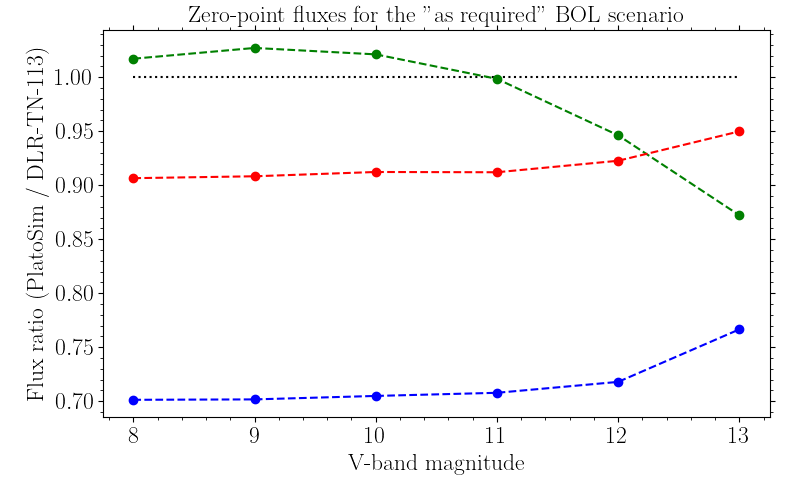

In [68]:
compare_results(cfgs, 'flux_required_BOL')
plt.title('Zero-point fluxes for the "as required" BOL scenario');

<IPython.core.display.Javascript object>


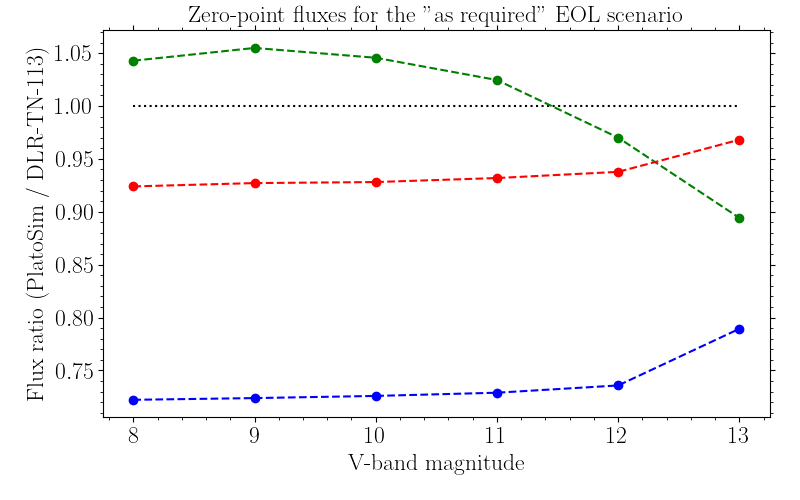

In [69]:
compare_results(cfgs, 'flux_required_EOL')
plt.title('Zero-point fluxes for the "as required" EOL scenario');

<IPython.core.display.Javascript object>


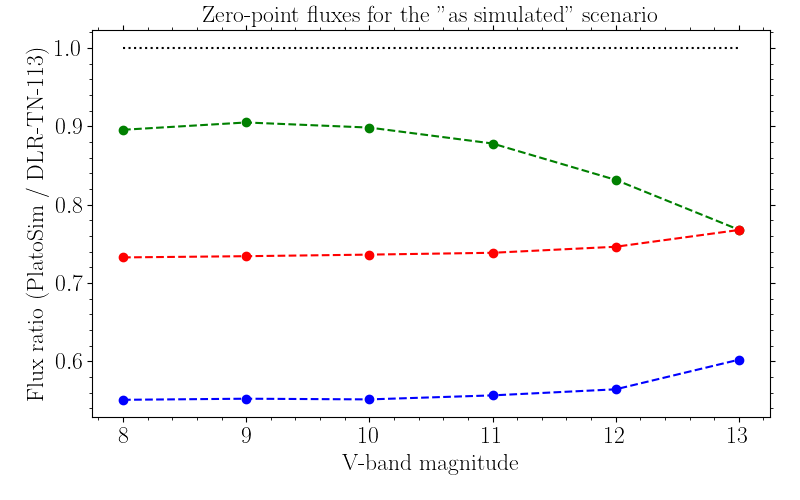

In [70]:
compare_results(cfgs, 'flux_simulate_BOL')
plt.title('Zero-point fluxes for the "as simulated" scenario');

#### Observations

We observe a strong magnitude dependece (creasing for the) N-CAMs and slight magnitude dependence (increasing) for the two F-CAMs. The dependence in magnitude in the PlatoSim results is unphysical and is not understood. We could explain a magnitude-independent offset.

### 7.2. Debug: Disable noise sources 
---
Here we investigate if the noise sources involved in the post-processing of the on-board photometry plays a role. We disable the following maps to check: 
- straylight
- point-like ghost
- flatfield
- darks
- BFE
- CTI
- smearing
- Gain non-linearity

In [71]:
# Here we extract the fluxes simulated with PlatoSim and compare with the tabulated values
for cfg in cfgs:
    cfg['flux'] = []
    v = cfg['Vmag']
    
    # Run for all magnitudes
    for i in tqdm(range(len(v)), bar_format=ut.tqdmBar(), desc=cfg['cam']):
        
        # Configure simulation
        outputFileName = cfg['cam'] + '_' + str(v[i])
        cfg_file = cfg['output_dir'] / cfg['cfg_file']
        cfg['psim'] = Simulation(outputFileName, configurationFile=cfg_file, outputDir=path)
        
        # Turn off certain noise effects
        cfg['psim']['Sky/StrayLight/IncludeStrayLight'] = False
        cfg['psim']['Camera/IncludePointLikeGhosts'] = False
        cfg['psim']['CCD/IncludeDarkSignal'] = False
        cfg['psim']['CCD/IncludeFlatfield']  = False
        cfg['psim']['CCD/IncludeOpenShutterSmearing'] = False
        cfg['psim']['CCD/IncludeCTIeffects'] = False
        cfg['psim']['CCD/IncludeBFE'] = False
        cfg['psim']['CCD/IncludeGainNonlinearity'] = False
        
        # Set up out subfield
        dim = 8
        cfg['psim']["SubField/ZeroPointRow"]    = 3000
        cfg['psim']["SubField/ZeroPointColumn"] = 3000
        cfg['psim']["SubField/NumColumns"]      = dim
        cfg['psim']["SubField/NumRows"]         = dim
    
        # My PlatoSim doesn't like this to be set to 'Custom'
        cfg['psim']['CCD/Position'] = 2
    
        # Create stellar catalogue
        row = np.array([dim/2]) + cfg['psim']["SubField/ZeroPointRow"]
        col = np.array([dim/2]) + cfg['psim']["SubField/ZeroPointColumn"]
        mag = np.array([cfg[passband][i]])
        ID  = np.array([0])
        starcatFile = cfg['output_dir'] / f'starcat_{cfg["cam"]}.txt'
        cfg['psim'].createStarCatalogFileFromPixelCoordinates(row, col, mag, ID, starcatFile)
    
        # Photometry file creation
        photometryFile = cfg['output_dir'] / f'photometry_{cfg["cam"]}_{str(v[i])}.txt'
        cfg['psim'].createPhotometryFile(ID, photometryFile)
        
        # Run simulation
        f = cfg['psim'].run(removeOutputFile=True)
        
        # Extract and append flux obtained through PlatoSim's Photometry library
        cfg['flux'].append(f.getFlux(0).mean())

F-CAMr: 100%|██████████████████████████████████████████████████| 6/6 [00:01<00:00,  3.47it/s]                                                                 


<IPython.core.display.Javascript object>


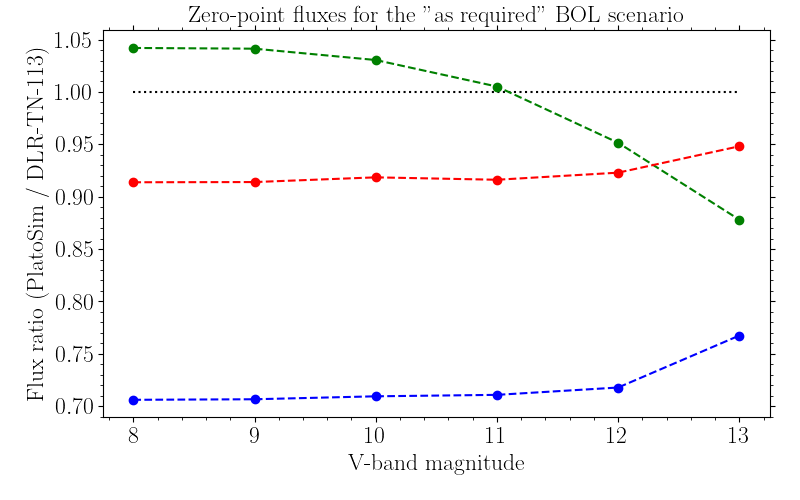

In [72]:
compare_results(cfgs, 'flux_required_BOL')
plt.title('Zero-point fluxes for the "as required" BOL scenario');

#### Observations

Overall we see that the magnitude dependence persits. We get slightly higher values, which is to be expected since we exclude several noise sources. Since the dependence seems stronger for fainter magnitudes, let's see what happens when we disable read noise.

In [73]:
# Here we extract the fluxes simulated with PlatoSim and compare with the tabulated values
for cfg in cfgs:
    cfg['flux'] = []
    v = cfg['Vmag']
    
    # Run for all magnitudes
    for i in tqdm(range(len(v)), bar_format=ut.tqdmBar(), desc=cfg['cam']):
        
        # Configure simulation
        outputFileName = cfg['cam'] + '_' + str(v[i])
        cfg_file = cfg['output_dir'] / cfg['cfg_file']
        cfg['psim'] = Simulation(outputFileName, configurationFile=cfg_file, outputDir=path)
        
        # Turn off certain noise effects
        cfg['psim']['Sky/StrayLight/IncludeStrayLight'] = False
        cfg['psim']['Camera/IncludePointLikeGhosts'] = False
        cfg['psim']['CCD/IncludeReadoutNoise'] = False
        cfg['psim']['CCD/IncludeDarkSignal'] = False
        cfg['psim']['CCD/IncludeFlatfield']  = False
        cfg['psim']['CCD/IncludeOpenShutterSmearing'] = False
        cfg['psim']['CCD/IncludeCTIeffects'] = False
        cfg['psim']['CCD/IncludeBFE'] = False
        cfg['psim']['CCD/IncludeGainNonlinearity'] = False
        
        # Set up out subfield
        dim = 8
        cfg['psim']["SubField/ZeroPointRow"]    = 3000
        cfg['psim']["SubField/ZeroPointColumn"] = 3000
        cfg['psim']["SubField/NumColumns"]      = dim
        cfg['psim']["SubField/NumRows"]         = dim
    
        # My PlatoSim doesn't like this to be set to 'Custom'
        cfg['psim']['CCD/Position'] = 2
    
        # Create stellar catalogue
        row = np.array([dim/2]) + cfg['psim']["SubField/ZeroPointRow"]
        col = np.array([dim/2]) + cfg['psim']["SubField/ZeroPointColumn"]
        mag = np.array([cfg[passband][i]])
        ID  = np.array([0])
        starcatFile = cfg['output_dir'] / f'starcat_{cfg["cam"]}.txt'
        cfg['psim'].createStarCatalogFileFromPixelCoordinates(row, col, mag, ID, starcatFile)
    
        # Photometry file creation
        photometryFile = cfg['output_dir'] / f'photometry_{cfg["cam"]}_{str(v[i])}.txt'
        cfg['psim'].createPhotometryFile(ID, photometryFile)
        
        # Run simulation
        f = cfg['psim'].run(removeOutputFile=True)
        
        # Extract and append flux obtained through PlatoSim's Photometry library
        cfg['flux'].append(f.getFlux(0).mean())

F-CAMr: 100%|██████████████████████████████████████████████████| 6/6 [00:01<00:00,  3.44it/s]                                                                 


<IPython.core.display.Javascript object>


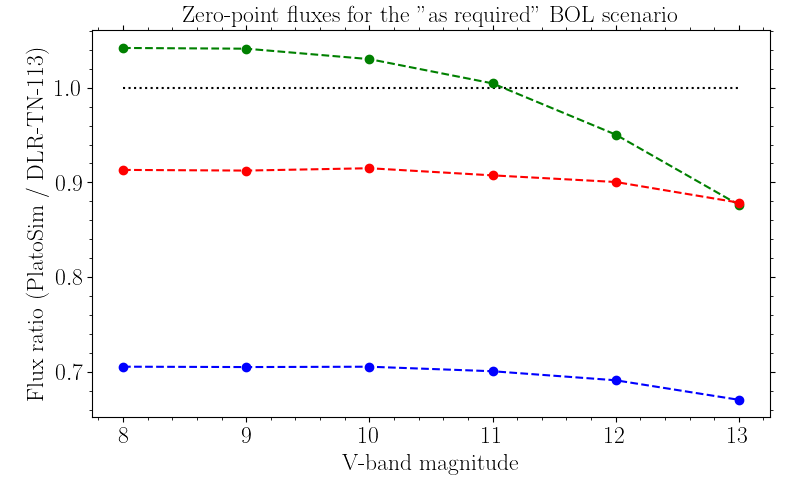

In [74]:
compare_results(cfgs, 'flux_required_BOL')
plt.title('Zero-point fluxes for the "as required" BOL scenario');

#### Observations

The read noise do not affect the N-CAM result, but does affect the F-CAM results.

### 7.3. Debug: Sum flux over entire subfield 
---
Here we investigate if the inclosed flux is not stable for the given on-board aperture mask. This may indicate that the on-board definition is badly implemented or not reliable for our purpose to estimate the zero-point flux. Since the on-board aperture mask algorithm also include a small reduction step taking into account for the bias, dark, flatfield, and smearing, we set the bias to 0 ADU and we disable the following maps to check:
- darks
- flatfield
- smearing

We first check that the background sums close to zero, as this is the base assumption for our method to work.

Bias subtracted image [ADU/exp]:
[[   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    1    4    2    0    0    0    0]
 [   0    0    0   41  164   87    8    0    0    0]
 [   0    0    4  184  987  839   54    0    0    0]
 [   0    0    4  129 1098 2592   80    0    0    0]
 [   0    0    0    8   75   95    4    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]]

Image used for flux estimate [e-/s]


<IPython.core.display.Javascript object>


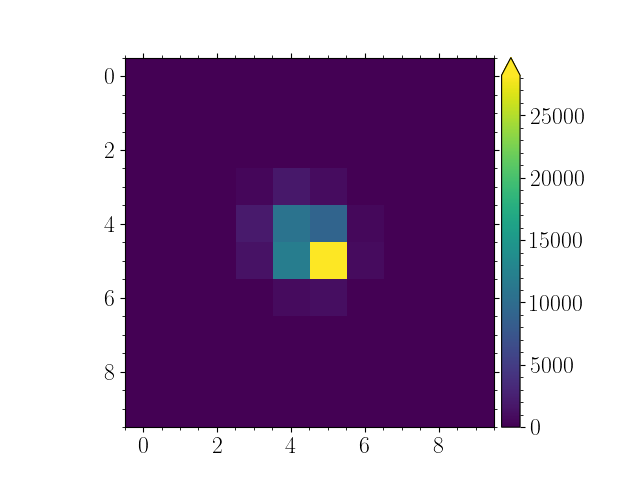

In [75]:
# We make a check using the N-CAMs for a V=8 magnitude star
Vmag = 8
cam = 'N-CAMs'
cam = 'F-CAMb'
cam = 'F-CAMr'
performance = 'required'
            
# Configure simulation
sim = Simulation('test', outputDir=path)
    
# We generate the default configurations
if cam == 'N-CAMs':
    sim.useNormalCamera(performance=performance)
elif cam == 'F-CAMb':
    sim.useFastCamera(passband='blue', performance=performance)
elif cam == 'F-CAMr':
    sim.useFastCamera(passband='red', performance=performance)

# Disable ghost as this is not comparable
sim['Camera/IncludePointLikeGhosts'] = False

# Disable any maps that needs to be accounted for in the post-processing
sim['CCD/IncludeReadoutNoise'] = False
sim['CCD/IncludeDarkSignal'] = False
sim['CCD/IncludeFlatfield']  = False
sim['CCD/IncludeOpenShutterSmearing'] = False
sim['CCD/IncludeCTIeffects'] = False
sim['CCD/IncludeBFE'] = False
sim['CCD/IncludeGainNonlinearity'] = False

# Disable several sky noise sources
sim['Sky/StrayLight/IncludeStrayLight'] = False
sim['Sky/SkyBackground/BackgroundValue'] = 0

# Set bias manually to make sure we understand it's origin
bias = 1000
sim['FEE/ElectronicOffset/RefValue'] = bias

# Check just one exposure
sim["ObservingParameters/NumExposures"] = 1

# Set up out subfield to an imagette
dim = 10
sim["SubField/ZeroPointRow"]    = 3000
sim["SubField/ZeroPointColumn"] = 3000
sim["SubField/NumColumns"]      = dim
sim["SubField/NumRows"]         = dim

# Create stellar catalogue
row = np.array([dim/2]) + sim["SubField/ZeroPointRow"]
col = np.array([dim/2]) + sim["SubField/ZeroPointColumn"]
mag = np.array([Vmag])
ID  = np.array([0])
starcatFile = cfg['output_dir'] / f'starcat_test.txt'
sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, ID, starcatFile)
        
# Run simulation
f = sim.run(removeOutputFile=True)
           
# Extract and append flux obtained through PlatoSim's Photometry library
im = f.getImage() - bias
print('Bias subtracted image [ADU/exp]:')
print(im)


gain = f.getGain()[0]
texp = f.getExposureTime()
im = im * gain / texp
print('\nImage used for flux estimate [e-/s]')
# print(im)

fig = plt.figure()
image = plt.imshow(im, cmap='viridis')
cbar = fig.colorbar(image, extend='max', shrink=1, pad=0.015)

Good, that seems to be the case. Let's check the flux estimates using this method:

In [76]:
# Here we extract the fluxes simulated with PlatoSim and compare with the tabulated values
for cfg in cfgs:
    cfg['flux'] = []
    v = cfg['Vmag']
    
    # Run for all magnitudes
    for i in tqdm(range(len(v)), bar_format=ut.tqdmBar(), desc=cfg['cam']):
        
        # Configure simulation
        outputFileName = cfg['cam'] + '_' + str(v[i])
        cfg_file = cfg['output_dir'] / cfg['cfg_file']
        cfg['psim'] = Simulation(outputFileName, configurationFile=cfg_file, outputDir=path)

        # Disable several sky noise sources
        cfg['psim']['Sky/StrayLight/IncludeStrayLight'] = False
        cfg['psim']['Sky/SkyBackground/BackgroundValue'] = 0

        # Disable ghost as this is not comparable
        cfg['psim']['Camera/IncludePointLikeGhosts'] = False

        # Disable any maps that needs to be accounted for in the post-processing
        cfg['psim']['CCD/IncludeReadoutNoise'] = False
        cfg['psim']['CCD/IncludeDarkSignal'] = False
        cfg['psim']['CCD/IncludeFlatfield']  = False
        cfg['psim']['CCD/IncludeOpenShutterSmearing'] = False
        cfg['psim']['CCD/IncludeCTIeffects'] = False
        cfg['psim']['CCD/IncludeBFE'] = False
        cfg['psim']['CCD/IncludeGainNonlinearity'] = False

        # Set bias manually to make sure we understand it's origin
        bias = 1000
        cfg['psim']['FEE/ElectronicOffset/RefValue'] = bias
    
        # Set up out subfield
        dim = 10
        cfg['psim']["SubField/ZeroPointRow"]    = 3000
        cfg['psim']["SubField/ZeroPointColumn"] = 3000
        cfg['psim']["SubField/NumColumns"]      = dim
        cfg['psim']["SubField/NumRows"]         = dim

        # Create stellar catalogue
        row = np.array([dim/2]) + cfg['psim']["SubField/ZeroPointRow"]
        col = np.array([dim/2]) + cfg['psim']["SubField/ZeroPointColumn"]
        mag = np.array([cfg[passband][i]])
        ID  = np.array([0])
        starcatFile = cfg['output_dir'] / f'starcat_{cfg["cam"]}.txt'
        cfg['psim'].createStarCatalogFileFromPixelCoordinates(row, col, mag, ID, starcatFile)
        
        # Run simulation
        f = cfg['psim'].run(removeOutputFile=True)
           
        # Extract and append flux from entire subfield
        gain = f.getGain()[0]
        texp = f.getExposureTime()
        im = f.getImage() - bias
        
        # Convert to e-/s
        im = im * gain / texp

        # Estimate flux [e-/s]
        N = im.shape[0]
        flux = np.zeros(N)
        for i in range(N):
            flux[i] = im[i].sum()        
        cfg['flux'].append(flux.mean())

F-CAMr: 100%|██████████████████████████████████████████████████| 6/6 [00:01<00:00,  3.43it/s]                                                                 


<IPython.core.display.Javascript object>


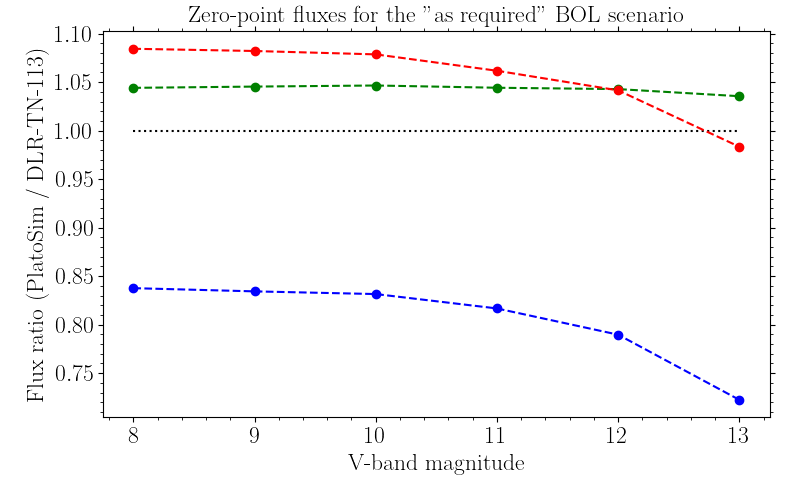

In [77]:
compare_results(cfgs, 'flux_required_BOL')
plt.title('Zero-point fluxes for the "as required" BOL scenario');

#### Observation

- N-CAMs: The magnitude dependence has almost disappeared using the subfield as a mask aperture. 
- F-CAMs: We now see a strong residual decreasing magnitude dependence. Enabling read noise makes this significantly worse for some reason (and it should not since the noise fluctuates around the bias level which we subtract, hence around 0 ADU essentially).

Assuming that the N-CAM simply fluctuates around a mean (no magnitude dependence), we can now try to see what the zero-point flux should be to make the results comparable to PLATO-DLR-TN-PL-0113. Practically, keeping the throughput fixed, one can only change net amount of photon flux in PlatoSim changing either the filter bandwidth or the zero-point reference flux. The central filter reference wavelength only dictates the amount of photon we receive from the sky background, but here we set it to zero, hence we should see no dependence from it: 

In [78]:
# Here we extract the fluxes simulated with PlatoSim and compare with the tabulated values
for cfg in cfgs:
    cfg['flux'] = []
    v = cfg['Vmag']
    
    # Run for all magnitudes
    for i in tqdm(range(len(v)), bar_format=ut.tqdmBar(), desc=cfg['cam']):
        
        # Configure simulation
        outputFileName = cfg['cam'] + '_' + str(v[i])
        cfg_file = cfg['output_dir'] / cfg['cfg_file']
        cfg['psim'] = Simulation(outputFileName, configurationFile=cfg_file, outputDir=path)
    
       # Set new bandwidth by try and error
        if cfg['cam'] == 'F-CAMb':
            cfg['psim']['Camera/ThroughputLambdaC'] = 500
        elif cfg['cam'] == 'F-CAMr':
            cfg['psim']['Camera/ThroughputLambdaC'] = 700

        # Disable several sky noise sources
        cfg['psim']['Sky/StrayLight/IncludeStrayLight'] = False
        cfg['psim']['Sky/SkyBackground/BackgroundValue'] = 0

        # Disable ghost as this is not comparable
        cfg['psim']['Camera/IncludePointLikeGhosts'] = False

        # Disable any maps that needs to be accounted for in the post-processing
        cfg['psim']['CCD/IncludeReadoutNoise'] = False
        cfg['psim']['CCD/IncludeDarkSignal'] = False
        cfg['psim']['CCD/IncludeFlatfield']  = False
        cfg['psim']['CCD/IncludeOpenShutterSmearing'] = False
        cfg['psim']['CCD/IncludeCTIeffects'] = False
        cfg['psim']['CCD/IncludeBFE'] = False
        cfg['psim']['CCD/IncludeGainNonlinearity'] = False

        # Set bias manually to make sure we understand it's origin
        bias = 1000
        cfg['psim']['FEE/ElectronicOffset/RefValue'] = bias
    
        # Set up out subfield
        dim = 10
        cfg['psim']["SubField/ZeroPointRow"]    = 3000
        cfg['psim']["SubField/ZeroPointColumn"] = 3000
        cfg['psim']["SubField/NumColumns"]      = dim
        cfg['psim']["SubField/NumRows"]         = dim

        # Create stellar catalogue
        row = np.array([dim/2]) + cfg['psim']["SubField/ZeroPointRow"]
        col = np.array([dim/2]) + cfg['psim']["SubField/ZeroPointColumn"]
        mag = np.array([cfg[passband][i]])
        ID  = np.array([0])
        starcatFile = cfg['output_dir'] / f'starcat_{cfg["cam"]}.txt'
        cfg['psim'].createStarCatalogFileFromPixelCoordinates(row, col, mag, ID, starcatFile)
        
        # Run simulation
        f = cfg['psim'].run(removeOutputFile=True)
           
        # Extract and append flux from entire subfield
        gain = f.getGain()[0]
        texp = f.getExposureTime()
        im = f.getImage() - bias
        
        # Convert to e-/s
        im = im * gain / texp

        # Estimate flux [e-/s]
        N = im.shape[0]
        flux = np.zeros(N)
        for i in range(N):
            flux[i] = im[i].sum()        
        cfg['flux'].append(flux.mean())

F-CAMr: 100%|██████████████████████████████████████████████████| 6/6 [00:01<00:00,  3.38it/s]                                                                 


<IPython.core.display.Javascript object>


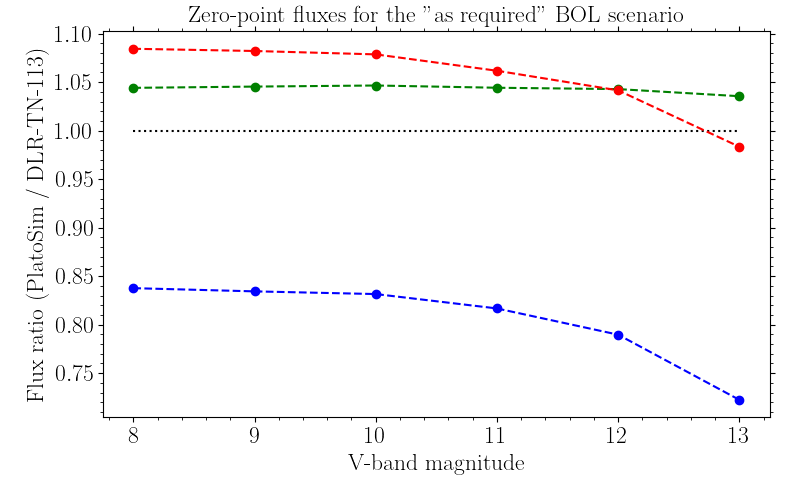

In [79]:
compare_results(cfgs, 'flux_required_BOL')
plt.title('Zero-point fluxes for the "as required" BOL scenario');

#### Observations

Indeed we can see that the central throughput wavelength does not change anything for our simulations when the sky background has been disabled.

We can now either change the zero-point reference flux or the bandwidth which should only shift the results in y-axis and not resolve the magnitude dependence. Let's start doing the former:

In [94]:
# Here we extract the fluxes simulated with PlatoSim and compare with the tabulated values
for cfg in cfgs:
    cfg['flux'] = []
    v = cfg['Vmag']
    
    # Run for all magnitudes
    for i in tqdm(range(len(v)), bar_format=ut.tqdmBar(), desc=cfg['cam']):
        
        # Configure simulation
        outputFileName = cfg['cam'] + '_' + str(v[i])
        cfg_file = cfg['output_dir'] / cfg['cfg_file']
        cfg['psim'] = Simulation(outputFileName, configurationFile=cfg_file, outputDir=path)
    
        # Set new zero-point flux by try-and-error
        if cfg['cam'] == 'N-CAMs':
            cfg['psim']['ObservingParameters/Fluxm0'] = 0.960e8
        elif cfg['cam'] == 'F-CAMb':
            cfg['psim']['ObservingParameters/Fluxm0'] = 1.195e8
        elif cfg['cam'] == 'F-CAMr':
            cfg['psim']['ObservingParameters/Fluxm0'] = 0.923e8

        # Disable several sky noise sources
        cfg['psim']['Sky/StrayLight/IncludeStrayLight'] = False
        cfg['psim']['Sky/SkyBackground/BackgroundValue'] = 0

        # Disable ghost as this is not comparable
        cfg['psim']['Camera/IncludePointLikeGhosts'] = False

        # Disable any maps that needs to be accounted for in the post-processing
        cfg['psim']['CCD/IncludeReadoutNoise'] = False
        cfg['psim']['CCD/IncludeDarkSignal'] = False
        cfg['psim']['CCD/IncludeFlatfield']  = False
        cfg['psim']['CCD/IncludeOpenShutterSmearing'] = False
        cfg['psim']['CCD/IncludeCTIeffects'] = False
        cfg['psim']['CCD/IncludeBFE'] = False
        cfg['psim']['CCD/IncludeGainNonlinearity'] = False

        # Set bias manually to make sure we understand it's origin
        bias = 1000
        cfg['psim']['FEE/ElectronicOffset/RefValue'] = bias
    
        # Set up out subfield
        dim = 10
        cfg['psim']["SubField/ZeroPointRow"]    = 3000
        cfg['psim']["SubField/ZeroPointColumn"] = 3000
        cfg['psim']["SubField/NumColumns"]      = dim
        cfg['psim']["SubField/NumRows"]         = dim

        # Create stellar catalogue
        row = np.array([dim/2]) + cfg['psim']["SubField/ZeroPointRow"]
        col = np.array([dim/2]) + cfg['psim']["SubField/ZeroPointColumn"]
        mag = np.array([cfg[passband][i]])
        ID  = np.array([0])
        starcatFile = cfg['output_dir'] / f'starcat_{cfg["cam"]}.txt'
        cfg['psim'].createStarCatalogFileFromPixelCoordinates(row, col, mag, ID, starcatFile)
        
        # Run simulation
        f = cfg['psim'].run(removeOutputFile=True)
           
        # Extract and append flux from entire subfield
        gain = f.getGain()[0]
        texp = f.getExposureTime()
        im = f.getImage() - bias
        
        # Convert to e-/s
        im = im * gain / texp

        # Estimate flux [e-/s]
        N = im.shape[0]
        flux = np.zeros(N)
        for i in range(N):
            flux[i] = im[i].sum()        
        cfg['flux'].append(flux.mean())

F-CAMr: 100%|██████████████████████████████████████████████████| 6/6 [00:01<00:00,  3.34it/s]                                                                 


<IPython.core.display.Javascript object>


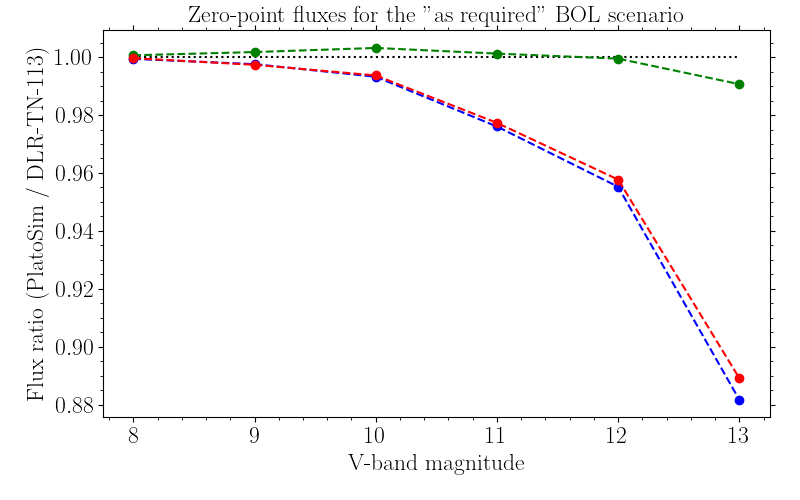

In [95]:
compare_results(cfgs, 'flux_required_BOL')
plt.title('Zero-point fluxes for the "as required" BOL scenario');

#### Observation

Hence, by try-and-error and using $V=8$ as a reference point, we get an agreement if:

- N-CAMs: $F(m=0) = 0.960 \times 10^8$ phot/s/m^2/nm 
- F-CAMb: $F(m=0) = 1.195 \times 10^8$ phot/s/m^2/nm 
- F-CAMr: $\,F(m=0) = 0.923 \times 10^8$ phot/s/m^2/nm 

We note that the value used by PlatoSim is standardly $F(m=0) = 1.00179 \times 10^8$ phot/s/m^2/nm. This value is made from a calculation that can be found in PLATO-KUL-TN-PL-0006 (also a notebook on the PlatoSim GitHub). I suspect that the old tables of Anko were used to estimate this value in that notebook.

To investigate why there is a strong magnitude dependence for the F-CAM, we try to look at the bandwidth that is defined in PlatoSim by the technical note PLATO-KUL-TN-PL-0006:

- F-CAMb: 165 nm
- F-CAMr: 335 nm

We note that these values are quite different from what is tabulated of Section 3.5. Note that the above calculations of this section uses the estimates of Section 3.5. 

The throughput bandwidth should in principle only control the total flux and not be depedent on magnitude:

In [102]:
# Here we extract the fluxes simulated with PlatoSim and compare with the tabulated values
for cfg in cfgs:
    cfg['flux'] = []
    v = cfg['Vmag']
    
    # Run for all magnitudes
    for i in tqdm(range(len(v)), bar_format=ut.tqdmBar(), desc=cfg['cam']):
        
        # Configure simulation
        outputFileName = cfg['cam'] + '_' + str(v[i])
        cfg_file = cfg['output_dir'] / cfg['cfg_file']
        cfg['psim'] = Simulation(outputFileName, configurationFile=cfg_file, outputDir=path)
    
        # Set new bandwidth by try-and-error
        if cfg['cam'] == 'N-CAMs':
            cfg['psim']['Camera/ThroughputBandwidth'] = 479
        elif cfg['cam'] == 'F-CAMb':
            cfg['psim']['Camera/ThroughputBandwidth'] = 173
        elif cfg['cam'] == 'F-CAMr':
            cfg['psim']['Camera/ThroughputBandwidth'] = 309

        # Disable several sky noise sources
        cfg['psim']['Sky/StrayLight/IncludeStrayLight'] = False
        cfg['psim']['Sky/SkyBackground/BackgroundValue'] = 0

        # Disable ghost as this is not comparable
        cfg['psim']['Camera/IncludePointLikeGhosts'] = False

        # Disable any maps that needs to be accounted for in the post-processing
        cfg['psim']['CCD/IncludeReadoutNoise'] = False
        cfg['psim']['CCD/IncludeDarkSignal'] = False
        cfg['psim']['CCD/IncludeFlatfield']  = False
        cfg['psim']['CCD/IncludeOpenShutterSmearing'] = False
        cfg['psim']['CCD/IncludeCTIeffects'] = False
        cfg['psim']['CCD/IncludeBFE'] = False
        cfg['psim']['CCD/IncludeGainNonlinearity'] = False

        # Set bias manually to make sure we understand it's origin
        bias = 1000
        cfg['psim']['FEE/ElectronicOffset/RefValue'] = bias
    
        # Set up out subfield
        dim = 10
        cfg['psim']["SubField/ZeroPointRow"]    = 3000
        cfg['psim']["SubField/ZeroPointColumn"] = 3000
        cfg['psim']["SubField/NumColumns"]      = dim
        cfg['psim']["SubField/NumRows"]         = dim

        # Create stellar catalogue
        row = np.array([dim/2]) + cfg['psim']["SubField/ZeroPointRow"]
        col = np.array([dim/2]) + cfg['psim']["SubField/ZeroPointColumn"]
        mag = np.array([cfg[passband][i]])
        ID  = np.array([0])
        starcatFile = cfg['output_dir'] / f'starcat_{cfg["cam"]}.txt'
        cfg['psim'].createStarCatalogFileFromPixelCoordinates(row, col, mag, ID, starcatFile)
        
        # Run simulation
        f = cfg['psim'].run(removeOutputFile=True)
           
        # Extract and append flux from entire subfield
        gain = f.getGain()[0]
        texp = f.getExposureTime()
        im = f.getImage() - bias
        
        # Convert to e-/s
        im = im * gain / texp

        # Estimate flux [e-/s]
        N = im.shape[0]
        flux = np.zeros(N)
        for i in range(N):
            flux[i] = im[i].sum()        
        cfg['flux'].append(flux.mean())

F-CAMr: 100%|██████████████████████████████████████████████████| 6/6 [00:01<00:00,  3.33it/s]                                                                 


<IPython.core.display.Javascript object>


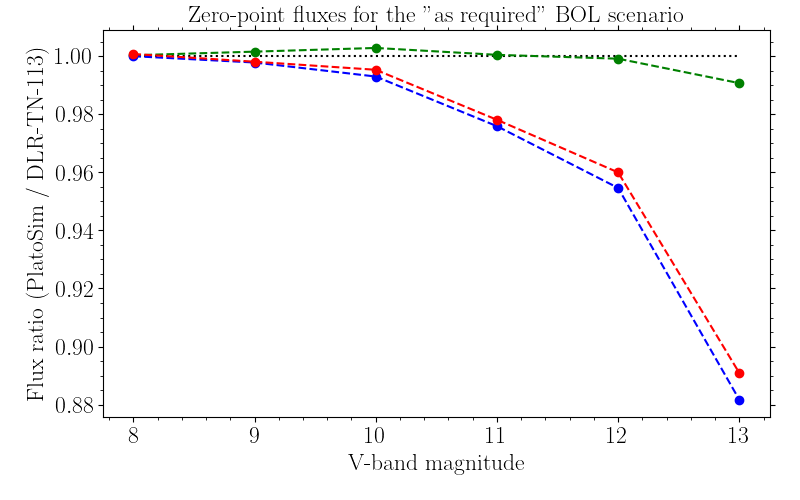

In [103]:
compare_results(cfgs, 'flux_required_BOL')
plt.title('Zero-point fluxes for the "as required" BOL scenario');

#### Observation

Assuming that the bright end estimates are correct, we find better estimates using the bandwidths:

- N-CAMs: 479 nm (before 532 nm)
- F-CAMb: 173 nm (before 165 nm)
- F-CAMr$\,$: 309 nm (before 335 nm)

Let's check how the photon noise impacts our results:

In [104]:
# Here we extract the fluxes simulated with PlatoSim and compare with the tabulated values
for cfg in cfgs:
    cfg['flux'] = []
    v = cfg['Vmag']
    
    # Run for all magnitudes
    for i in tqdm(range(len(v)), bar_format=ut.tqdmBar(), desc=cfg['cam']):
        
        # Configure simulation
        outputFileName = cfg['cam'] + '_' + str(v[i])
        cfg_file = cfg['output_dir'] / cfg['cfg_file']
        cfg['psim'] = Simulation(outputFileName, configurationFile=cfg_file, outputDir=path)
    
        # Set new bandwidth by try-and-error
        if cfg['cam'] == 'N-CAMs':
            cfg['psim']['Camera/ThroughputBandwidth'] = 479
        elif cfg['cam'] == 'F-CAMb':
            cfg['psim']['Camera/ThroughputBandwidth'] = 173
        elif cfg['cam'] == 'F-CAMr':
            cfg['psim']['Camera/ThroughputBandwidth'] = 309

        # Disable several sky noise sources
        cfg['psim']['Sky/StrayLight/IncludeStrayLight'] = False
        cfg['psim']['Sky/SkyBackground/BackgroundValue'] = 0

        # Disable ghost as this is not comparable
        cfg['psim']['Camera/IncludePointLikeGhosts'] = False

        # Disable any maps that needs to be accounted for in the post-processing
        cfg['psim']['CCD/IncludePhotonNoise'] = False
        cfg['psim']['CCD/IncludeReadoutNoise'] = False
        cfg['psim']['CCD/IncludeDarkSignal'] = False
        cfg['psim']['CCD/IncludeFlatfield']  = False
        cfg['psim']['CCD/IncludeOpenShutterSmearing'] = False
        cfg['psim']['CCD/IncludeCTIeffects'] = False
        cfg['psim']['CCD/IncludeBFE'] = False
        cfg['psim']['CCD/IncludeGainNonlinearity'] = False

        # Set bias manually to make sure we understand it's origin
        bias = 1000
        cfg['psim']['FEE/ElectronicOffset/RefValue'] = bias
    
        # Set up out subfield
        dim = 10
        cfg['psim']["SubField/ZeroPointRow"]    = 3000
        cfg['psim']["SubField/ZeroPointColumn"] = 3000
        cfg['psim']["SubField/NumColumns"]      = dim
        cfg['psim']["SubField/NumRows"]         = dim

        # Create stellar catalogue
        row = np.array([dim/2]) + cfg['psim']["SubField/ZeroPointRow"]
        col = np.array([dim/2]) + cfg['psim']["SubField/ZeroPointColumn"]
        mag = np.array([cfg[passband][i]])
        ID  = np.array([0])
        starcatFile = cfg['output_dir'] / f'starcat_{cfg["cam"]}.txt'
        cfg['psim'].createStarCatalogFileFromPixelCoordinates(row, col, mag, ID, starcatFile)
        
        # Run simulation
        f = cfg['psim'].run(removeOutputFile=True)
           
        # Extract and append flux from entire subfield
        gain = f.getGain()[0]
        texp = f.getExposureTime()
        im = f.getImage() - bias
        
        # Convert to e-/s
        im = im * gain / texp

        # Estimate flux [e-/s]
        N = im.shape[0]
        flux = np.zeros(N)
        for i in range(N):
            flux[i] = im[i].sum()        
        cfg['flux'].append(flux.mean())

F-CAMr: 100%|██████████████████████████████████████████████████| 6/6 [00:01<00:00,  3.42it/s]                                                                 


<IPython.core.display.Javascript object>


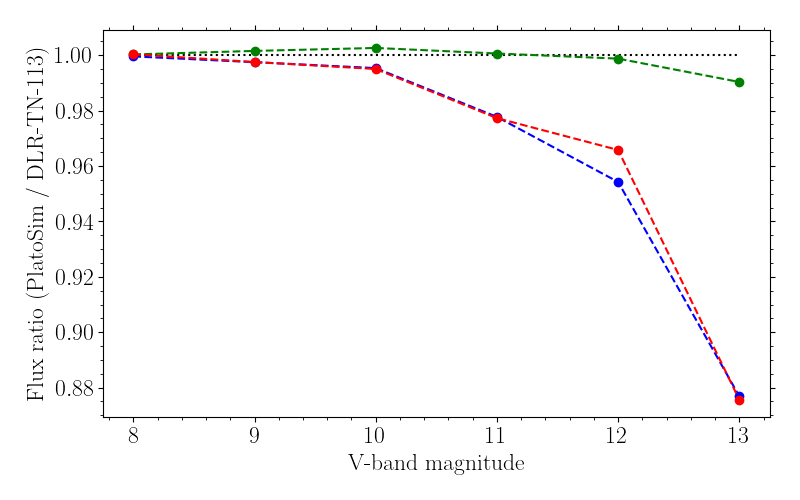

In [105]:
compare_results(cfgs, 'flux_required_BOL');

#### Observations

Suprisingly, the photon noise does affect the results. The magnitude dependence of the F-CAMr get less pronouced in the faint end. Also the F-CAMb improves slightly. It doesn't not solve the issue, but it is clear that the underlying noise in the simulations affect the flux ratio.

---
### Concluding remark

**Nicholas 2025-06-04:** 
- Regarding the zero-point flux discrepancy only looking at the offset in flux levels between PlatoSim and PLATO-DLR-TN-PL-0113, the most logical thing to be seems fixing the bandwidth to the different requirements and use the above (or perhaps refined) estimates of the `Fluxm0` value in PlatoSim. But is it expected to have different `Fluxm0` values for the N-CAM, F-CAMb, and F-CAMr? 
- Regarding the magnitude dependence observed, we need to have a deeper discussion and look into the source code among the PlatoSim team (hence, involve Joris and Dries). It looks to me that we are not using the same theoretical formalism to calculate the flux $F$. What is even more strange is why the dependence it stronger for the two F-CAMs than the N-CAM?

---
## 8. Debugging zero point fluxes
---

The equation that defines the zero point and fluxes are discussed in chapter 3 of PLATO-UPD-SCI-TN-0019 and chapter 5 of PLATO-DLR-PL-TN-0113 (see also Marchiori et al. 2019, Jannsen et al. 2024):

$ P_\mathrm{ZP} = 2.5 * \mathrm{log}_{10} \left[ \frac{\Theta}{hc} \int_{\lambda_\mathrm{min}}^{\lambda_\mathrm{max}} d\lambda \, \lambda \, f_\mathrm{Vega}(\lambda) \, S(\lambda) \right] + P_\mathrm{Vega}$ ,

with $P_\mathrm{Vega} = 0.23$ and:

$ P = -2.5 \mathrm{log}_{10} F + P_\mathrm{ZP}$ .

Above (see chapter 7) the $P$ magnitudes are tabulated inputs from PLATO-DLR-PL-TN-0113. We want to compare the tabulated fluxes in PLATO-DLR-PL-TN-0113 with the simulated values by PlatoSim, which use the transmission and efficiency paramters described in chapters 4, 5, and 6. So, in principle, it is trivial, from the fluxes and the $P$ magnitudes, to test the zero points $P_\mathrm{ZP}$ and try to figure out the discrepancies.

In [75]:
def debug_zeropoints_results(cfgs, flux_table):
    """
    So this function compares the zero points computed by PlatoSim and the tabulated
    values in PLATO-DLR-PL-TN-0113.
    
    We take as inputs a list of dictionaries (cfgs) that contains PlatoSim configuration
    information for the N-CAM, F-CAM blue, and F-CAM red and tabulated values for the
    magnitudes and fluxes from PLATO-DLR-PL-TN-0113. See chapter 7 for the definition
    of the variable. Pay attention to how the keyword 'flux' of each dictionary has 
    been computed with PlatoSim using the yaml file provided as configuration and the
    PlatoSim function getFlux() from simfile.py.
    
    The second input (flux_table) is a string that defines the scenario (required, 
    designed, etc.). See chapter 3 for the definitions. The string must be one of the 
    existing keys in the dictionaries contained in 'cfgs', namely 'flux_simulate_BOL',
    'flux_required_BOL', or 'flux_required_EOL'.
    """
    
    def zp(p, f):
        return p + 2.5*np.log10(f)
    
    print('Zero-point magnitudes computed by PlatoSim and tabulated in PLATO-DLR-PL-TN-0113')
    print('     N-CAM     F-CAM blue   F-CAM red')
    with np.printoptions(precision=2, suppress=True):
        print(np.array(( 
            zp(cfgs[0]['Pmag'], cfgs[0]['flux']),
            zp(cfgs[0]['Pmag'], cfgs[0][flux_table]),
            zp(cfgs[1]['Pmag'], cfgs[1]['flux']),
            zp(cfgs[1]['Pmag'], cfgs[1][flux_table]),
            zp(cfgs[2]['Pmag'], cfgs[2]['flux']),
            zp(cfgs[2]['Pmag'], cfgs[2][flux_table]),  
                         )).T)

In [76]:
# Juan 03.06.2025 -> here we have excellent agreement between 
# N-CAMs and F-CAM red while we are only 14% away for F-CAM blue
# which is not bad. Could be related to the bandwith, actually.
#
# The expected zeropoints for the required BOL scenario
# are (see Tables 3 to 5 in PLATO-DLR-PL-TN-0113)
# 20.64, 19.93, and 19.58 respectively for the 
# N-CAM, F-CAM blue, and F-CAM red
debug_zeropoints_results(cfgs, 'flux_required_BOL')

Zero-point magnitudes computed by PlatoSim and tabulated in PLATO-DLR-PL-TN-0113
     N-CAM     F-CAM blue   F-CAM red
[[20.64 20.64 19.79 19.93 19.56 19.57]
 [20.64 20.64 19.78 19.93 19.56 19.57]
 [20.64 20.64 19.78 19.92 19.55 19.57]
 [20.64 20.64 19.76 19.93 19.54 19.58]
 [20.64 20.64 19.71 19.92 19.52 19.57]
 [20.63 20.64 19.64 19.93 19.42 19.57]]


In [77]:
# Juan 03.06.2025 -> we do the EOL values are the 
# same for PlatoSim as the BOL values?
#
# The expected zeropoints for the required EOL scenario
# are (see Tables 3 to 5 in PLATO-DLR-PL-TN-0113)
# 20.61, 19.89, and 19.55 respectively for the 
# N-CAM, F-CAM blue, and F-CAM red
debug_zeropoints_results(cfgs, 'flux_required_EOL')

Zero-point magnitudes computed by PlatoSim and tabulated in PLATO-DLR-PL-TN-0113
     N-CAM     F-CAM blue   F-CAM red
[[20.64 20.62 19.79 19.89 19.56 19.55]
 [20.64 20.61 19.78 19.89 19.56 19.55]
 [20.64 20.61 19.78 19.89 19.55 19.55]
 [20.64 20.61 19.76 19.89 19.54 19.55]
 [20.64 20.61 19.71 19.9  19.52 19.56]
 [20.63 20.62 19.64 19.89 19.42 19.55]]


In [78]:
# Juan 03.06.2025 -> this comparison is actually not
# valid because we are testing PlatoSim with 'required'
# so I suggest to remove this line
#
# The expected zeropoints for the simulated scenario
# are (see Tables 3 to 5 in PLATO-DLR-PL-TN-0113)
# 20.78, 20.19, and 19.81 respectively for the 
# N-CAM, F-CAM blue, and F-CAM red
debug_zeropoints_results(cfgs, 'flux_simulate_BOL')

Zero-point magnitudes computed by PlatoSim and tabulated in PLATO-DLR-PL-TN-0113
     N-CAM     F-CAM blue   F-CAM red
[[20.64 20.78 19.79 20.19 19.56 19.81]
 [20.64 20.78 19.78 20.19 19.56 19.81]
 [20.64 20.78 19.78 20.19 19.55 19.8 ]
 [20.64 20.78 19.76 20.19 19.54 19.8 ]
 [20.64 20.78 19.71 20.19 19.52 19.8 ]
 [20.63 20.78 19.64 20.19 19.42 19.81]]
